<a href="https://colab.research.google.com/github/nallievira/handwriting-writer-identification/blob/main/535240023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!nvidia-smi

Sun Jun 14 15:03:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#**BIAR GAK RUN ULANG**

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image

output_dir = '/content/drive/MyDrive/ML_UAS'

final_df = pd.read_csv(os.path.join(output_dir, 'final_handwriting_dataset.csv'))
label_mapping_df = pd.read_csv(os.path.join(output_dir, 'label_mapping.csv'))

train_80_df = pd.read_csv(os.path.join(output_dir, 'train_80.csv'))
test_20_df = pd.read_csv(os.path.join(output_dir, 'test_20.csv'))

train_70_df = pd.read_csv(os.path.join(output_dir, 'train_70.csv'))
test_30_df = pd.read_csv(os.path.join(output_dir, 'test_30.csv'))

print("final_df:", final_df.shape)
print("train_80_df:", train_80_df.shape)
print("test_20_df:", test_20_df.shape)
print("train_70_df:", train_70_df.shape)
print("test_30_df:", test_30_df.shape)

final_df: (6400, 3)
train_80_df: (5120, 3)
test_20_df: (1280, 3)
train_70_df: (4480, 3)
test_30_df: (1920, 3)


#**1. Dataset Preparation and Pre-Processing**

**1. Import Library untuk Cek Dataset**

In [ ]:
import os #baca file & folder
from PIL import Image #cek gambar rusak/ngga
import pandas as pd #bkin tabel audit
import matplotlib.pyplot as plt #buat grafik distribusi dataset

**3. Cek path Folder di GoogleDrive**

In [ ]:
dataset_path = '/content/drive/MyDrive/MACHINE LEARNING_2026/MLA/MLA'
print("Dataset path:", dataset_path)
print("Apakah folder ditemukan?", os.path.exists(dataset_path))

Dataset path: /content/drive/MyDrive/MACHINE LEARNING_2026/MLA/MLA
Apakah folder ditemukan? True


**4. Cek Folder Class & Penulis**

In [ ]:
class_folders = sorted([
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
])

print("Jumlah folder/class ditemukan:", len(class_folders))
print("Contoh nama folder/class:")
print(class_folders[:10])

Jumlah folder/class ditemukan: 64
Contoh nama folder/class:
['A220002', 'A220006', 'A220007', 'A220012', 'A220014', 'A220021', 'A220022', 'A220028', 'A220031', 'A220032']


**5. Hitung jumlah gambar dalam setiap class**

In [ ]:
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

audit_data = []

for class_name in class_folders:
    class_path = os.path.join(dataset_path, class_name)

    image_files = []

    for root, dirs, files in os.walk(class_path):
        for file in files:
            if file.lower().endswith(valid_extensions):
                image_files.append(os.path.join(root, file))

    audit_data.append({
        'class_name': class_name,
        'image_count': len(image_files)
    })

audit_df = pd.DataFrame(audit_data)

display(audit_df)

print("Jumlah class:", len(audit_df))
print("Total gambar:", audit_df['image_count'].sum())
print("Jumlah gambar minimum per class:", audit_df['image_count'].min())
print("Jumlah gambar maksimum per class:", audit_df['image_count'].max())

,class_name,image_count
0,A220002,100
1,A220006,100
2,A220007,100
3,A220012,100
4,A220014,100
...,...,...
59,A220241,100
60,A220245,100
61,A220247,100
62,A220259,100


Jumlah class: 64
Total gambar: 6400
Jumlah gambar minimum per class: 100
Jumlah gambar maksimum per class: 100


**6. Cek class yang jumlah gambar bukan 100**

In [ ]:
expected_count = 100

problem_classes = audit_df[audit_df['image_count'] != expected_count]

if problem_classes.empty:
    print("Semua class memiliki 100 gambar. Dataset seimbang.")
else:
    print("Ada class yang jumlah gambarnya tidak sesuai:")
    display(problem_classes)

Semua class memiliki 100 gambar. Dataset seimbang.


**7. Cek file/gambar ga kebaca/rusak**

In [ ]:
corrupted_files = []
valid_image_paths = []

for class_name in class_folders:
    class_path = os.path.join(dataset_path, class_name)

    for root, dirs, files in os.walk(class_path):
        for file_name in files:
            if file_name.lower().endswith(valid_extensions):
                file_path = os.path.join(root, file_name)

                try:
                    with Image.open(file_path) as img:
                        img.verify()

                    valid_image_paths.append({
                        'class_name': class_name,
                        'file_path': file_path
                    })

                except Exception as e:
                    corrupted_files.append({
                        'class_name': class_name,
                        'file_name': file_name,
                        'file_path': file_path,
                        'error': str(e)
                    })

corrupted_df = pd.DataFrame(corrupted_files)
valid_paths_df = pd.DataFrame(valid_image_paths)

print("Total gambar valid terbaca:", len(valid_paths_df))
print("Jumlah file rusak/tidak terbaca:", len(corrupted_df))

if len(corrupted_df) > 0:
    display(corrupted_df)
else:
    print("Tidak ditemukan file rusak. Semua gambar dapat dibaca.")

Total gambar valid terbaca: 6400
Jumlah file rusak/tidak terbaca: 0
Tidak ditemukan file rusak. Semua gambar dapat dibaca.


**7.1 Cek ulang apakah gambar valid tetap 6.400**

In [ ]:
if len(valid_paths_df) == 6400 and len(corrupted_df) == 0:
    print("Status validitas file: AMAN")
else:
    print("Status validitas file: PERLU DIPERIKSA")

Status validitas file: AMAN


**7.2 Simpan daftar path gambar valid**

In [ ]:
os.makedirs('/content/drive/MyDrive/ML_UAS', exist_ok=True)

valid_paths_output = '/content/drive/MyDrive/ML_UAS/valid_image_paths.csv'
valid_paths_df.to_csv(valid_paths_output, index=False)

print("Daftar path gambar valid disimpan di:")
print(valid_paths_output)

Daftar path gambar valid disimpan di:
/content/drive/MyDrive/ML_UAS/valid_image_paths.csv


**8. Grafik distribusi jumlah gambar per class**

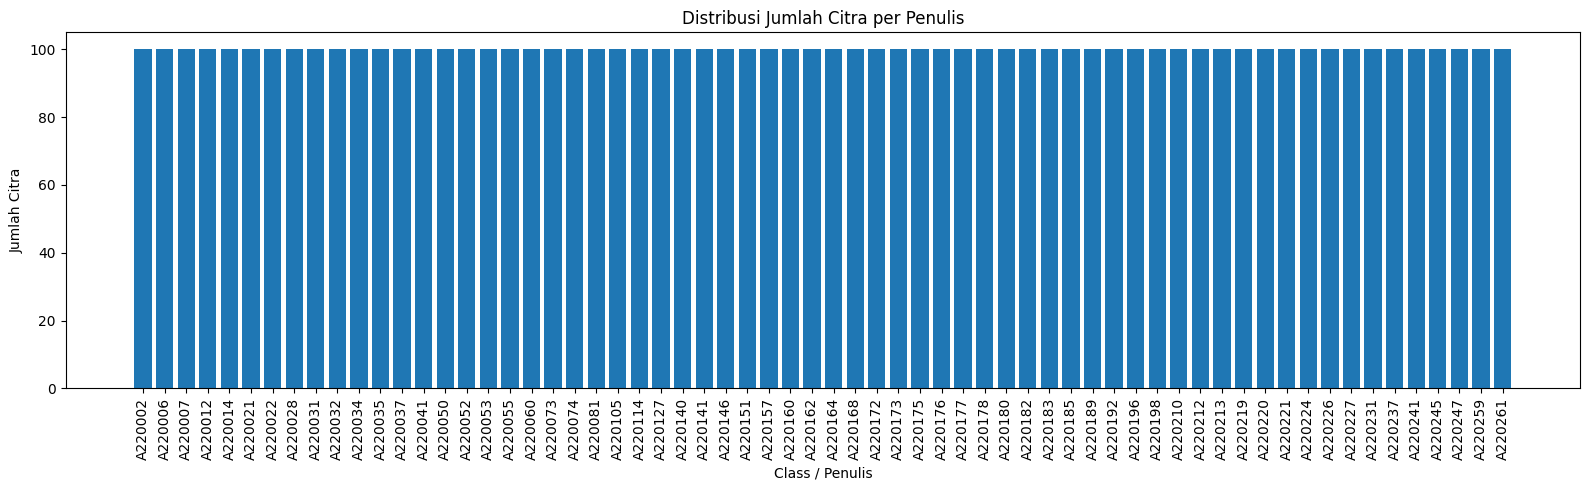

In [ ]:
plt.figure(figsize=(16, 5))
plt.bar(audit_df['class_name'], audit_df['image_count'])
plt.xticks(rotation=90)
plt.xlabel('Class / Penulis')
plt.ylabel('Jumlah Citra')
plt.title('Distribusi Jumlah Citra per Penulis')
plt.tight_layout()
plt.show()

**9. Inspeksi Visual dan Audit Ukuran Citra**

**9.1 Tampilkan contoh gambar random**

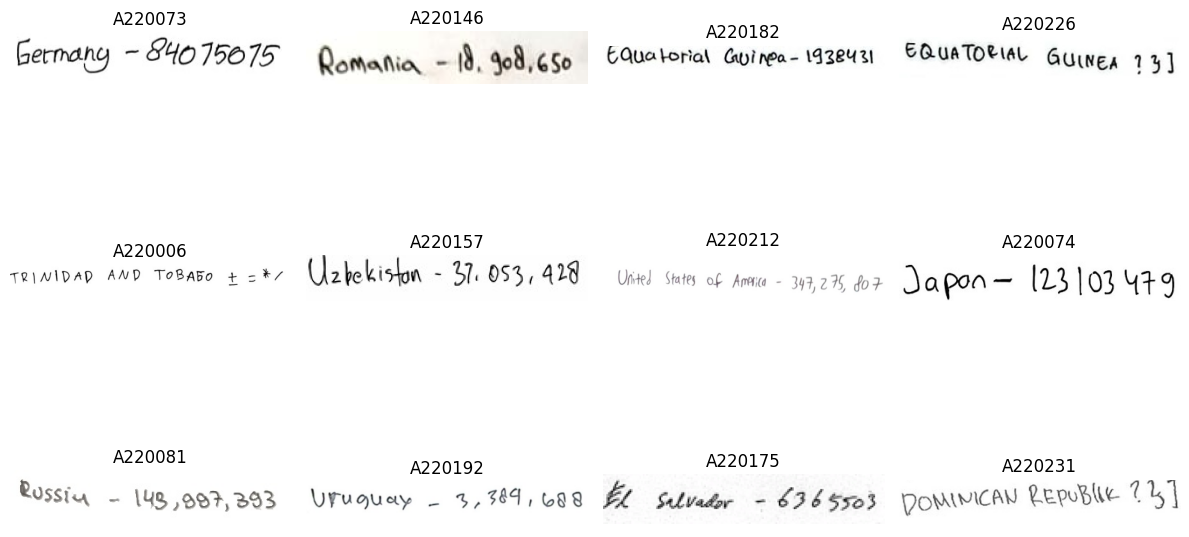

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

sample_df = valid_paths_df.sample(12, random_state=42)

plt.figure(figsize=(12, 8))

for idx, row in enumerate(sample_df.itertuples(), 1):
    img = Image.open(row.file_path)

    plt.subplot(3, 4, idx)
    plt.imshow(img)
    plt.title(row.class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

**9.2 Tampilkan satu contoh dari beberapa class berbeda**

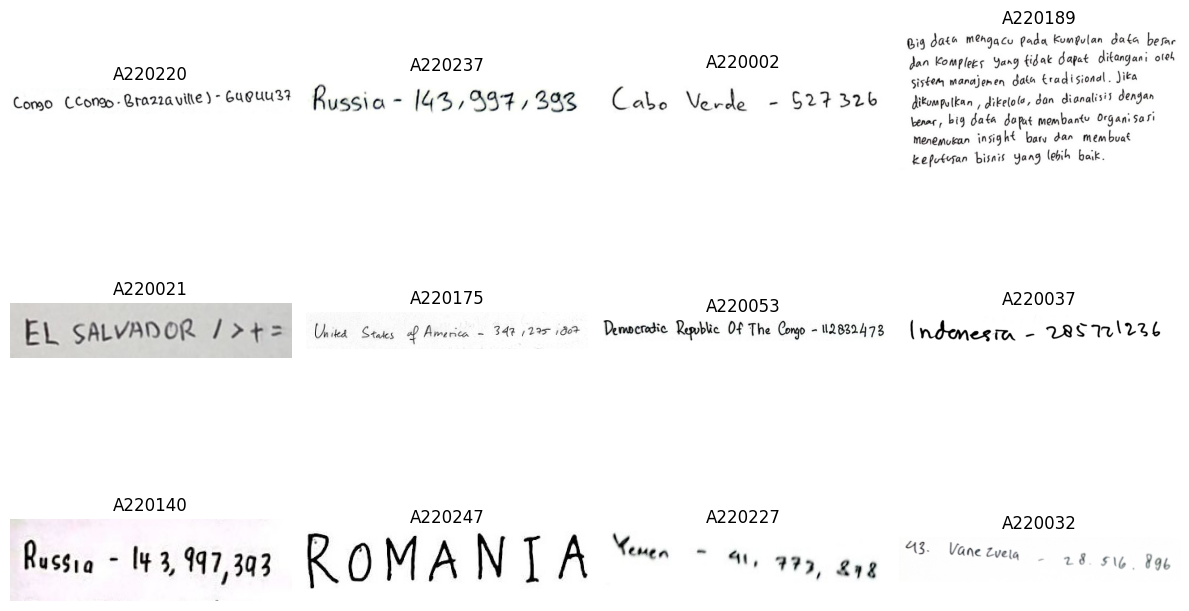

In [ ]:
selected_classes = valid_paths_df['class_name'].drop_duplicates().sample(12, random_state=42)

plt.figure(figsize=(12, 8))

for idx, class_name in enumerate(selected_classes, 1):
    class_sample = valid_paths_df[valid_paths_df['class_name'] == class_name].sample(1, random_state=42)
    file_path = class_sample.iloc[0]['file_path']

    img = Image.open(file_path)

    plt.subplot(3, 4, idx)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

**9.3 Audit ukuran asli seluruh gambar**

In [ ]:
image_size_data = []

for row in valid_paths_df.itertuples():
    with Image.open(row.file_path) as img:
        width, height = img.size

    image_size_data.append({
        'class_name': row.class_name,
        'file_path': row.file_path,
        'width': width,
        'height': height
    })

image_size_df = pd.DataFrame(image_size_data)

display(image_size_df.head())

print("Jumlah variasi ukuran gambar:", image_size_df[['width', 'height']].drop_duplicates().shape[0])
print("Width minimum:", image_size_df['width'].min())
print("Width maksimum:", image_size_df['width'].max())
print("Height minimum:", image_size_df['height'].min())
print("Height maksimum:", image_size_df['height'].max())

,class_name,file_path,width,height
0,A220002,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,364,64
1,A220002,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,457,81
2,A220002,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,313,59
3,A220002,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,723,74
4,A220002,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,689,74


Jumlah variasi ukuran gambar: 5983
Width minimum: 87
Width maksimum: 5344
Height minimum: 14
Height maksimum: 1862


**9.4 Lihat ukuran gambar yang paling sering muncul**

In [ ]:
size_summary = image_size_df.groupby(['width', 'height']).size().reset_index(name='count')
size_summary = size_summary.sort_values(by='count', ascending=False)

display(size_summary.head(20))

,width,height,count
5693,1726,124,8
4323,708,129,5
307,192,38,4
602,226,31,4
1395,305,54,4
1152,281,60,3
97,157,37,3
2778,453,83,3
624,227,41,3
667,232,46,3


**9.5 Simpan hasil audit ukuran gambar**

In [ ]:
image_size_output = '/content/drive/MyDrive/ML_UAS/image_size_audit.csv'
image_size_df.to_csv(image_size_output, index=False)

print("Hasil audit ukuran gambar disimpan di:")
print(image_size_output)

Hasil audit ukuran gambar disimpan di:
/content/drive/MyDrive/ML_UAS/image_size_audit.csv


**10. Audit Outlier Dimensi Citra**

Cari gambar yang ukurannya terlalu kecil, terlalu besar, atau rasio panjang-lebarnya ekstrem sebelum dilakukan resize.

**10.1 Tambahkan aspect ratio**

In [ ]:
image_size_df['aspect_ratio'] = image_size_df['width'] / image_size_df['height']

display(image_size_df.head())

print("Aspect ratio minimum:", image_size_df['aspect_ratio'].min())
print("Aspect ratio maksimum:", image_size_df['aspect_ratio'].max())
print("Aspect ratio rata-rata:", image_size_df['aspect_ratio'].mean())

,class_name,file_path,width,height,aspect_ratio
0,A220002,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,364,64,5.687500
1,A220002,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,457,81,5.641975
2,A220002,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,313,59,5.305085
3,A220002,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,723,74,9.770270
4,A220002,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,689,74,9.310811


Aspect ratio minimum: 0.46125
Aspect ratio maksimum: 18.083333333333332
Aspect ratio rata-rata: 6.825407207385277


**10.2 Cari gambar terlalu kecil**

In [ ]:
small_images = image_size_df[
    (image_size_df['width'] < 100) |
    (image_size_df['height'] < 50)
]

print("Jumlah gambar terlalu kecil:", len(small_images))
display(small_images.head(30))

Jumlah gambar terlalu kecil: 1722


,class_name,file_path,width,height,aspect_ratio
146,A220006,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,432,47,9.191489
147,A220006,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,344,46,7.478261
151,A220006,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,493,42,11.738095
153,A220006,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,442,42,10.523810
164,A220006,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,417,39,10.692308
175,A220006,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,414,44,9.409091
180,A220006,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,341,49,6.959184
188,A220006,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,475,48,9.895833
196,A220006,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,460,46,10.000000
205,A220007,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,321,43,7.465116


**10.3 Cari gambar terlalu besar**

In [ ]:
large_images = image_size_df[
    (image_size_df['width'] > 4000) |
    (image_size_df['height'] > 1500)
]

print("Jumlah gambar terlalu besar:", len(large_images))
display(large_images.head(30))

Jumlah gambar terlalu besar: 7


,class_name,file_path,width,height,aspect_ratio
943,A220032,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,3259,1862,1.750269
986,A220032,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,4404,316,13.936709
1235,A220037,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,4088,348,11.747126
1274,A220037,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,4744,268,17.701493
1453,A220050,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,5344,356,15.011236
2355,A220114,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,3021,1539,1.962963
5730,A220231,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,738,1600,0.461250


**10.4 Cari aspect ratio ekstrem**

In [ ]:
extreme_ratio_images = image_size_df[
    (image_size_df['aspect_ratio'] < 1.5) |
    (image_size_df['aspect_ratio'] > 25)
]

print("Jumlah gambar dengan aspect ratio ekstrem:", len(extreme_ratio_images))
display(extreme_ratio_images.head(30))

Jumlah gambar dengan aspect ratio ekstrem: 16


,class_name,file_path,width,height,aspect_ratio
620,A220022,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,454,363,1.250689
1677,A220053,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,1217,816,1.491422
1681,A220053,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,1215,864,1.406250
2280,A220105,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,377,297,1.269360
2597,A220140,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,1600,1142,1.401051
2687,A220141,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,1497,1030,1.453398
4251,A220183,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,903,685,1.318248
4949,A220212,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,377,262,1.438931
4988,A220212,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,568,421,1.349169
4991,A220212,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,466,371,1.256065


**10.5 Tampilkan contoh gambar bermasalah**

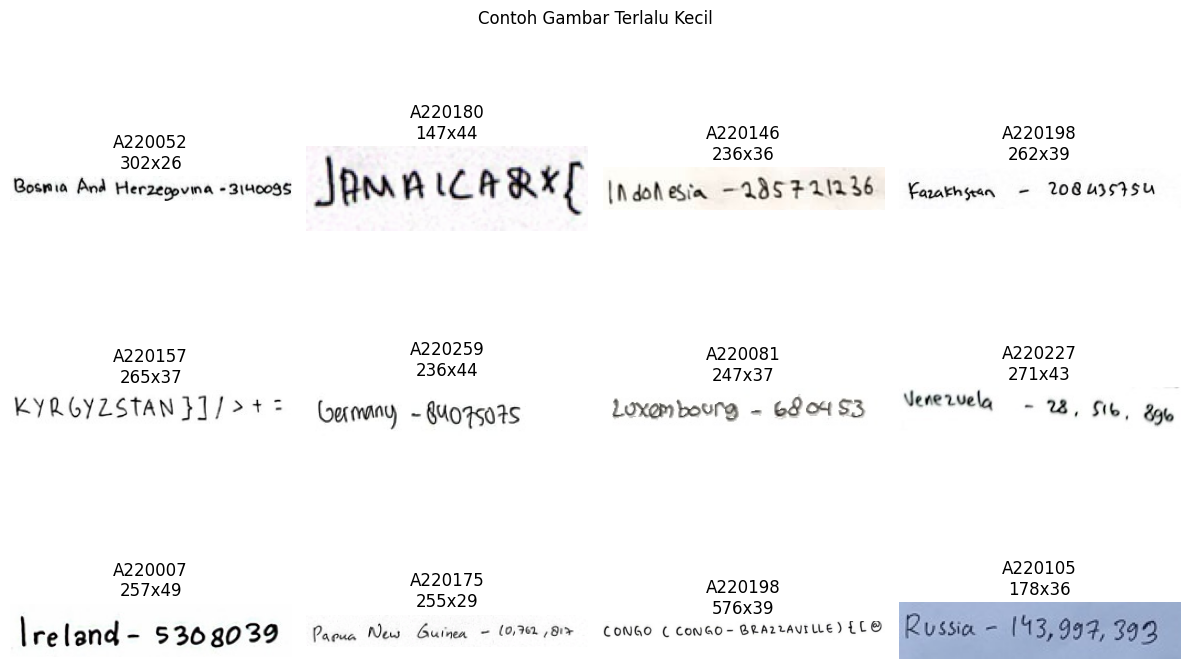

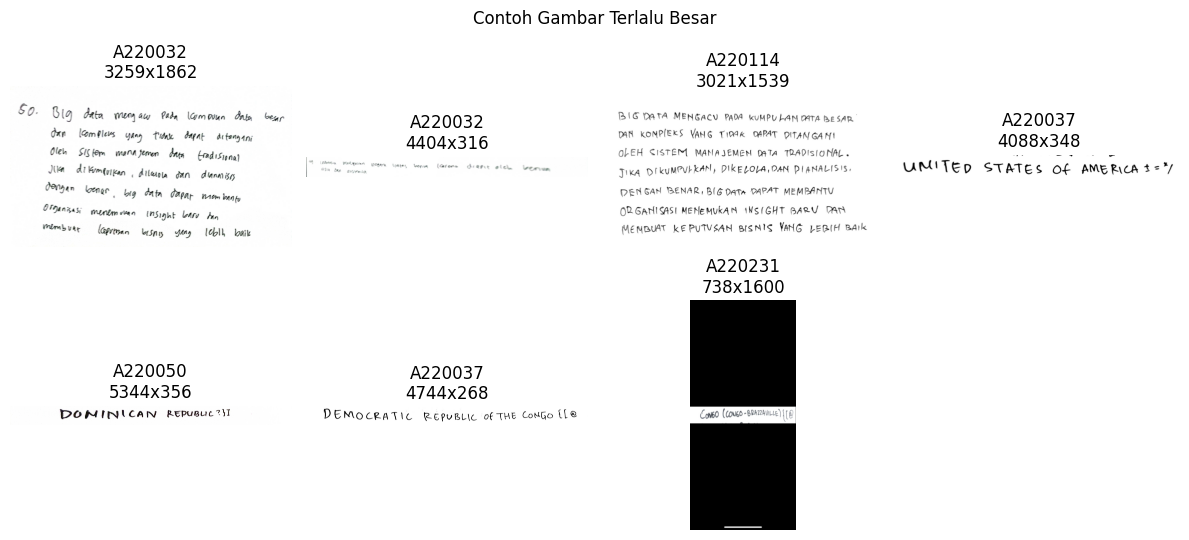

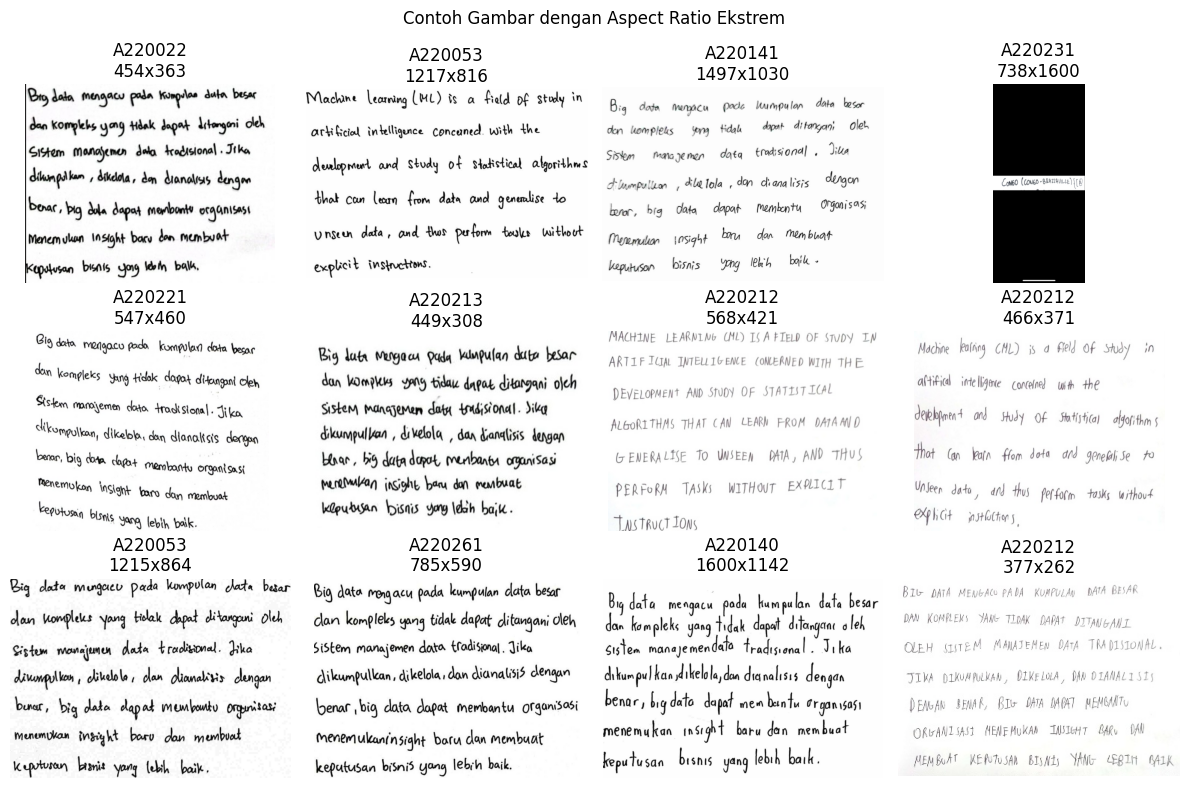

In [ ]:
def show_images(df, title, n=12):
    if len(df) == 0:
        print(f"Tidak ada gambar untuk kategori: {title}")
        return

    sample = df.sample(min(n, len(df)), random_state=42)

    plt.figure(figsize=(12, 8))

    for idx, row in enumerate(sample.itertuples(), 1):
        img = Image.open(row.file_path)

        plt.subplot(3, 4, idx)
        plt.imshow(img)
        plt.title(f"{row.class_name}\n{row.width}x{row.height}")
        plt.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_images(small_images, "Contoh Gambar Terlalu Kecil")
show_images(large_images, "Contoh Gambar Terlalu Besar")
show_images(extreme_ratio_images, "Contoh Gambar dengan Aspect Ratio Ekstrem")

**11. Resize dengan Padding**

**11.1 Function resize dengan padding**

In [ ]:
from PIL import Image, ImageOps
import numpy as np

def resize_with_padding(image, target_size=(299, 299), fill_color=(255, 255, 255)):
    """
    Resize image while preserving aspect ratio, then pad to target size.

    Parameters:
    image: PIL Image
    target_size: tuple, target width and height
    fill_color: padding color, white by default

    Returns:
    PIL Image with target_size
    """

    #pastikan gambar RGB
    image = image.convert("RGB")

    original_width, original_height = image.size
    target_width, target_height = target_size

    #hitung rasio scaling tanpa merusak aspect ratio
    scale = min(target_width / original_width, target_height / original_height)

    new_width = int(original_width * scale)
    new_height = int(original_height * scale)

    #resize gambar
    resized_image = image.resize((new_width, new_height), Image.Resampling.LANCZOS)

    #buat canvas putih ukuran target
    padded_image = Image.new("RGB", target_size, fill_color)

    #hitung posisi supaya gambar berada di tengah
    paste_x = (target_width - new_width) // 2
    paste_y = (target_height - new_height) // 2

    #tempel gambar hasil resize ke canvas putih
    padded_image.paste(resized_image, (paste_x, paste_y))

    return padded_image

**11.2 Tes pada beberapa gambar kecil**

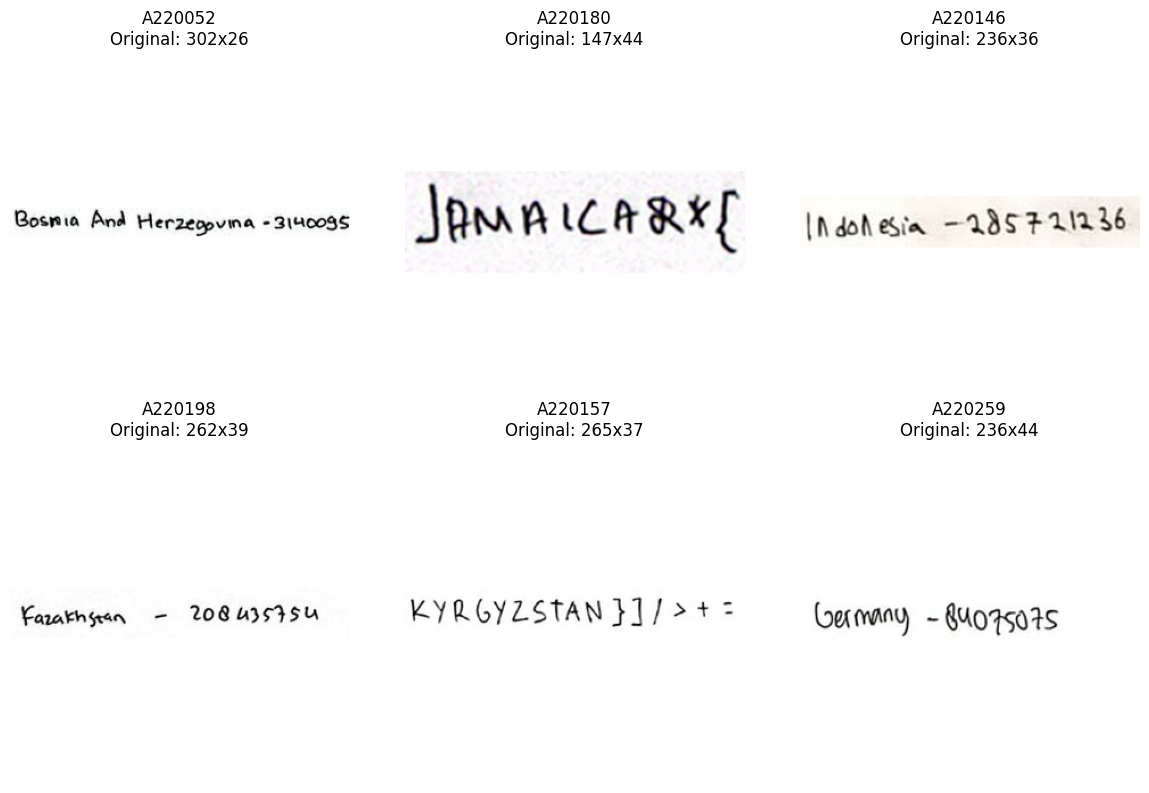

In [ ]:
sample_small = small_images.sample(6, random_state=42)

plt.figure(figsize=(12, 8))

for idx, row in enumerate(sample_small.itertuples(), 1):
    original_img = Image.open(row.file_path)
    processed_img = resize_with_padding(original_img, target_size=(299, 299))

    plt.subplot(2, 3, idx)
    plt.imshow(processed_img)
    plt.title(f"{row.class_name}\nOriginal: {row.width}x{row.height}")
    plt.axis('off')

plt.tight_layout()
plt.show()

**11.3 Bandingkan original vs resize biasa vs padding**

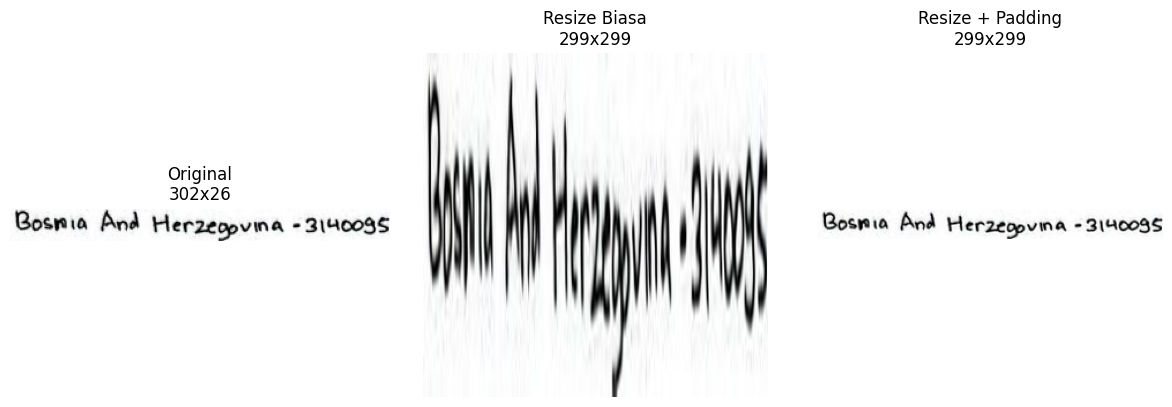

In [ ]:
sample_row = small_images.sample(1, random_state=42).iloc[0]
original_img = Image.open(sample_row['file_path']).convert("RGB")

normal_resize = original_img.resize((299, 299), Image.Resampling.LANCZOS)
padding_resize = resize_with_padding(original_img, target_size=(299, 299))

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(original_img)
plt.title(f"Original\n{sample_row['width']}x{sample_row['height']}")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(normal_resize)
plt.title("Resize Biasa\n299x299")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(padding_resize)
plt.title("Resize + Padding\n299x299")
plt.axis('off')

plt.tight_layout()
plt.show()

**12. Buat DataFrame Final Path + Label**

In [ ]:
valid_paths_df.head()

,class_name,file_path
0,A220002,/content/drive/MyDrive/MACHINE LEARNING_2026/M...
1,A220002,/content/drive/MyDrive/MACHINE LEARNING_2026/M...
2,A220002,/content/drive/MyDrive/MACHINE LEARNING_2026/M...
3,A220002,/content/drive/MyDrive/MACHINE LEARNING_2026/M...
4,A220002,/content/drive/MyDrive/MACHINE LEARNING_2026/M...


**12.1 Buat label angka untuk setiap penulis**

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

final_df = valid_paths_df.copy()
final_df['label'] = label_encoder.fit_transform(final_df['class_name'])

display(final_df.head())

print("Jumlah data:", len(final_df))
print("Jumlah class:", final_df['class_name'].nunique())
print("Label minimum:", final_df['label'].min())
print("Label maksimum:", final_df['label'].max())

,class_name,file_path,label
0,A220002,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,0
1,A220002,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,0
2,A220002,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,0
3,A220002,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,0
4,A220002,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,0


Jumlah data: 6400
Jumlah class: 64
Label minimum: 0
Label maksimum: 63


**12.3 Cek mapping class ke label**

In [ ]:
label_mapping_df = pd.DataFrame({
    'class_name': label_encoder.classes_,
    'label': range(len(label_encoder.classes_))
})

display(label_mapping_df.head(20))

,class_name,label
0,A220002,0
1,A220006,1
2,A220007,2
3,A220012,3
4,A220014,4
5,A220021,5
6,A220022,6
7,A220028,7
8,A220031,8
9,A220032,9


**12.4 Cek distribusi label final**

In [ ]:
label_distribution = final_df.groupby(['class_name', 'label']).size().reset_index(name='image_count')

display(label_distribution)

print("Minimum gambar per label:", label_distribution['image_count'].min())
print("Maksimum gambar per label:", label_distribution['image_count'].max())

,class_name,label,image_count
0,A220002,0,100
1,A220006,1,100
2,A220007,2,100
3,A220012,3,100
4,A220014,4,100
...,...,...,...
59,A220241,59,100
60,A220245,60,100
61,A220247,61,100
62,A220259,62,100


Minimum gambar per label: 100
Maksimum gambar per label: 100


**12.5 Acak urutan data**

In [ ]:
final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

display(final_df.head())

,class_name,file_path,label
0,A220073,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,19
1,A220146,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,27
2,A220182,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,41
3,A220226,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,55
4,A220006,/content/drive/MyDrive/MACHINE LEARNING_2026/M...,1


**12.6 Simpan dataframe final ke CSV**

In [ ]:
import os

output_dir = '/content/drive/MyDrive/ML_UAS'
os.makedirs(output_dir, exist_ok=True)

final_df_path = os.path.join(output_dir, 'final_handwriting_dataset.csv')
label_mapping_path = os.path.join(output_dir, 'label_mapping.csv')

final_df.to_csv(final_df_path, index=False)
label_mapping_df.to_csv(label_mapping_path, index=False)

print("Final dataset CSV disimpan di:", final_df_path)
print("Label mapping CSV disimpan di:", label_mapping_path)

Final dataset CSV disimpan di: /content/drive/MyDrive/ML_UAS/final_handwriting_dataset.csv
Label mapping CSV disimpan di: /content/drive/MyDrive/ML_UAS/label_mapping.csv


#**2. Data Splitting**

**13.1 Import library split**

In [ ]:
from sklearn.model_selection import train_test_split

**13.2 Split 80:20 Stratified**

In [ ]:
train_80_df, test_20_df = train_test_split(
    final_df,
    test_size=0.20,
    random_state=42,
    stratify=final_df['label']
)

print("Train 80%:", len(train_80_df))
print("Test 20%:", len(test_20_df))

print("\nDistribusi train per class:")
print(train_80_df['label'].value_counts().sort_index().unique())

print("\nDistribusi test per class:")
print(test_20_df['label'].value_counts().sort_index().unique())

Train 80%: 5120
Test 20%: 1280

Distribusi train per class:
[80]

Distribusi test per class:
[20]


**13.3 Split 70:30 Stratified**

In [ ]:
train_70_df, test_30_df = train_test_split(
    final_df,
    test_size=0.30,
    random_state=42,
    stratify=final_df['label']
)

print("Train 70%:", len(train_70_df))
print("Test 30%:", len(test_30_df))

print("\nDistribusi train per class:")
print(train_70_df['label'].value_counts().sort_index().unique())

print("\nDistribusi test per class:")
print(test_30_df['label'].value_counts().sort_index().unique())

Train 70%: 4480
Test 30%: 1920

Distribusi train per class:
[70]

Distribusi test per class:
[30]


**13.4 Simpan hasil split ke CSV**

In [ ]:
train_80_df.to_csv(os.path.join(output_dir, 'train_80.csv'), index=False)
test_20_df.to_csv(os.path.join(output_dir, 'test_20.csv'), index=False)

train_70_df.to_csv(os.path.join(output_dir, 'train_70.csv'), index=False)
test_30_df.to_csv(os.path.join(output_dir, 'test_30.csv'), index=False)

print("Semua file split berhasil disimpan.")

Semua file split berhasil disimpan.


**13.5 Ringkasan Split**

In [ ]:
print("RINGKASAN SPLIT DATASET")
print(f"Total dataset        : {len(final_df)} citra")
print(f"Jumlah class         : {final_df['label'].nunique()} penulis")
print()

print("Split 80:20")
print(f"Train               : {len(train_80_df)} citra")
print(f"Test                : {len(test_20_df)} citra")
print(f"Train per class      : {train_80_df['label'].value_counts().sort_index().unique()}")
print(f"Test per class       : {test_20_df['label'].value_counts().sort_index().unique()}")
print()

print("Split 70:30")
print(f"Train               : {len(train_70_df)} citra")
print(f"Test                : {len(test_30_df)} citra")
print(f"Train per class      : {train_70_df['label'].value_counts().sort_index().unique()}")
print(f"Test per class       : {test_30_df['label'].value_counts().sort_index().unique()}")

RINGKASAN SPLIT DATASET
Total dataset        : 6400 citra
Jumlah class         : 64 penulis

Split 80:20
Train               : 5120 citra
Test                : 1280 citra
Train per class      : [80]
Test per class       : [20]

Split 70:30
Train               : 4480 citra
Test                : 1920 citra
Train per class      : [70]
Test per class       : [30]


#**3. Image Pre-Processing Pipeline**

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

In [ ]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


**a.Set konfigurasi utama**

In [ ]:
IMG_SIZE = 299
BATCH_SIZE = 32
NUM_CLASSES = 64

**b. Pastikan fungsi resize + padding ada**

In [ ]:
from PIL import Image

def resize_with_padding(image, target_size=(299, 299), fill_color=(255, 255, 255)):
    image = image.convert("RGB")

    original_width, original_height = image.size
    target_width, target_height = target_size

    scale = min(target_width / original_width, target_height / original_height)

    new_width = int(original_width * scale)
    new_height = int(original_height * scale)

    resized_image = image.resize((new_width, new_height), Image.Resampling.LANCZOS)

    padded_image = Image.new("RGB", target_size, fill_color)

    paste_x = (target_width - new_width) // 2
    paste_y = (target_height - new_height) // 2

    padded_image.paste(resized_image, (paste_x, paste_y))

    return padded_image

**c. Buat fungsi load image untuk CNN**

In [ ]:
def load_image_for_cnn(file_path, label):
    image = Image.open(file_path)
    image = resize_with_padding(image, target_size=(IMG_SIZE, IMG_SIZE))
    image_array = np.array(image).astype("float32") / 255.0

    label = int(label)

    return image_array, label

**d. Tes load satu gambar**

In [ ]:
sample_path = final_df.iloc[0]['file_path']
sample_label = final_df.iloc[0]['label']

sample_image, sample_label_output = load_image_for_cnn(sample_path, sample_label)

print("Shape image:", sample_image.shape)
print("Min pixel:", sample_image.min())
print("Max pixel:", sample_image.max())
print("Label:", sample_label_output)

Shape image: (299, 299, 3)
Min pixel: 0.0
Max pixel: 1.0
Label: 19


**e. Tampilkan hasil load image**

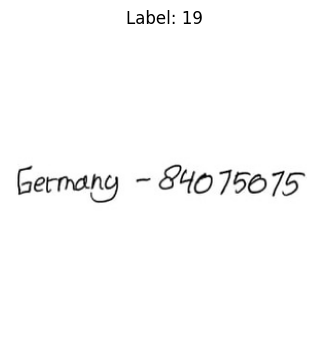

In [ ]:
plt.figure(figsize=(4, 4))
plt.imshow(sample_image)
plt.title(f"Label: {sample_label_output}")
plt.axis("off")
plt.show()

**f. Buat TensorFlow Dataset**

In [ ]:
def load_image_tf(file_path, label):
    image = tf.io.read_file(file_path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])

    image = tf.cast(image, tf.float32) / 255.0

    original_shape = tf.shape(image)
    original_height = tf.cast(original_shape[0], tf.float32)
    original_width = tf.cast(original_shape[1], tf.float32)

    scale = tf.minimum(
        IMG_SIZE / original_width,
        IMG_SIZE / original_height
    )

    new_width = tf.cast(original_width * scale, tf.int32)
    new_height = tf.cast(original_height * scale, tf.int32)

    image = tf.image.resize(image, [new_height, new_width])

    pad_height = IMG_SIZE - new_height
    pad_width = IMG_SIZE - new_width

    pad_top = pad_height // 2
    pad_bottom = pad_height - pad_top
    pad_left = pad_width // 2
    pad_right = pad_width - pad_left

    image = tf.pad(
        image,
        paddings=[
            [pad_top, pad_bottom],
            [pad_left, pad_right],
            [0, 0]
        ],
        constant_values=1.0
    )

    image.set_shape([IMG_SIZE, IMG_SIZE, 3])

    label = tf.cast(label, tf.int32)

    return image, label

In [ ]:
def create_tf_dataset(df, batch_size=32, shuffle=True):
    file_paths = df['file_path'].values
    labels = df['label'].values

    dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=512, seed=42)

    dataset = dataset.map(load_image_tf, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

**g. Cek batch 80/20**

In [ ]:
train_80_ds = create_tf_dataset(train_80_df, batch_size=BATCH_SIZE, shuffle=True)
test_20_ds = create_tf_dataset(test_20_df, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
for images, labels in train_80_ds.take(1):
    print("Batch image shape:", images.shape)
    print("Batch label shape:", labels.shape)
    print("Min pixel:", tf.reduce_min(images).numpy())
    print("Max pixel:", tf.reduce_max(images).numpy())

Batch image shape: (32, 299, 299, 3)
Batch label shape: (32,)
Min pixel: 0.0
Max pixel: 1.0


**h. Visualisasi batch pertama**

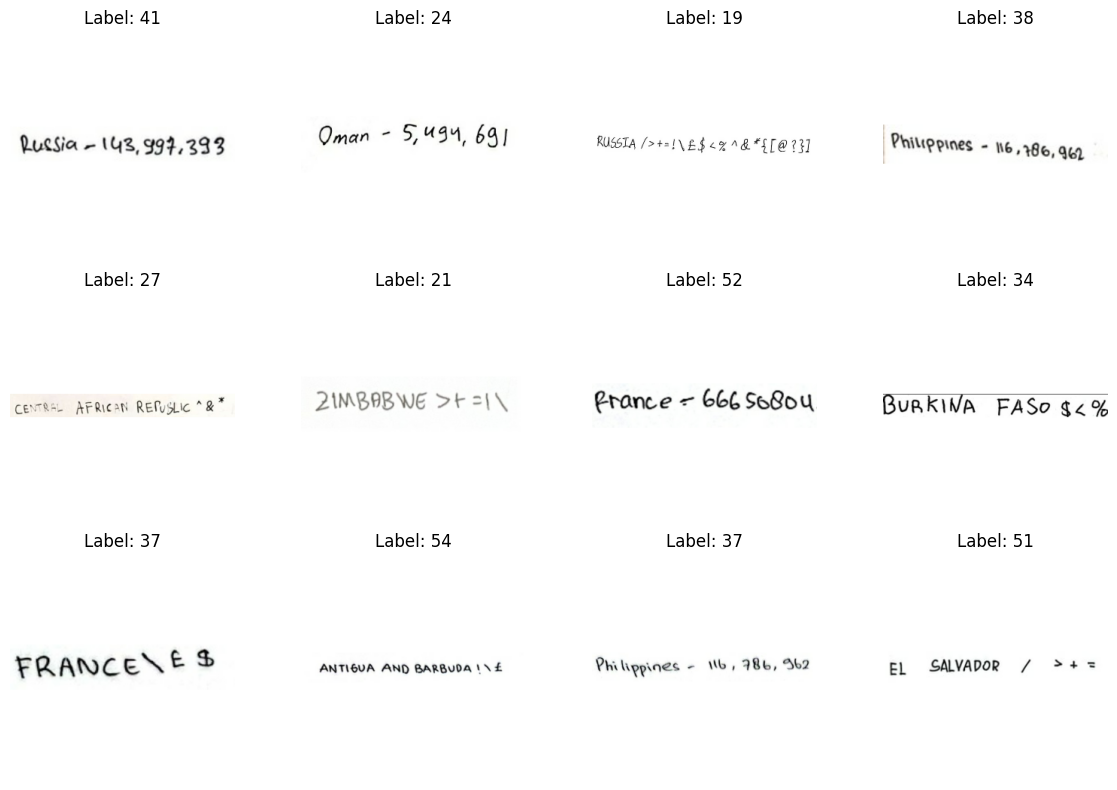

In [ ]:
plt.figure(figsize=(12, 8))

for images, labels in train_80_ds.take(1):
    for i in range(12):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i])
        plt.title(f"Label: {labels[i].numpy()}")
        plt.axis("off")

plt.tight_layout()
plt.show()

**i. Buat dataset 70/30**

In [ ]:
train_70_ds = create_tf_dataset(train_70_df, batch_size=BATCH_SIZE, shuffle=True)
test_30_ds = create_tf_dataset(test_30_df, batch_size=BATCH_SIZE, shuffle=False)

**j. Cek batch 70:30**

In [ ]:
for images, labels in train_70_ds.take(1):
    print("Batch image shape:", images.shape)
    print("Batch label shape:", labels.shape)
    print("Min pixel:", tf.reduce_min(images).numpy())
    print("Max pixel:", tf.reduce_max(images).numpy())
    print("Labels:", labels[:10].numpy())

Batch image shape: (32, 299, 299, 3)
Batch label shape: (32,)
Min pixel: 0.0
Max pixel: 1.0
Labels: [39 31 41 51 40 18  1 44 53  7]


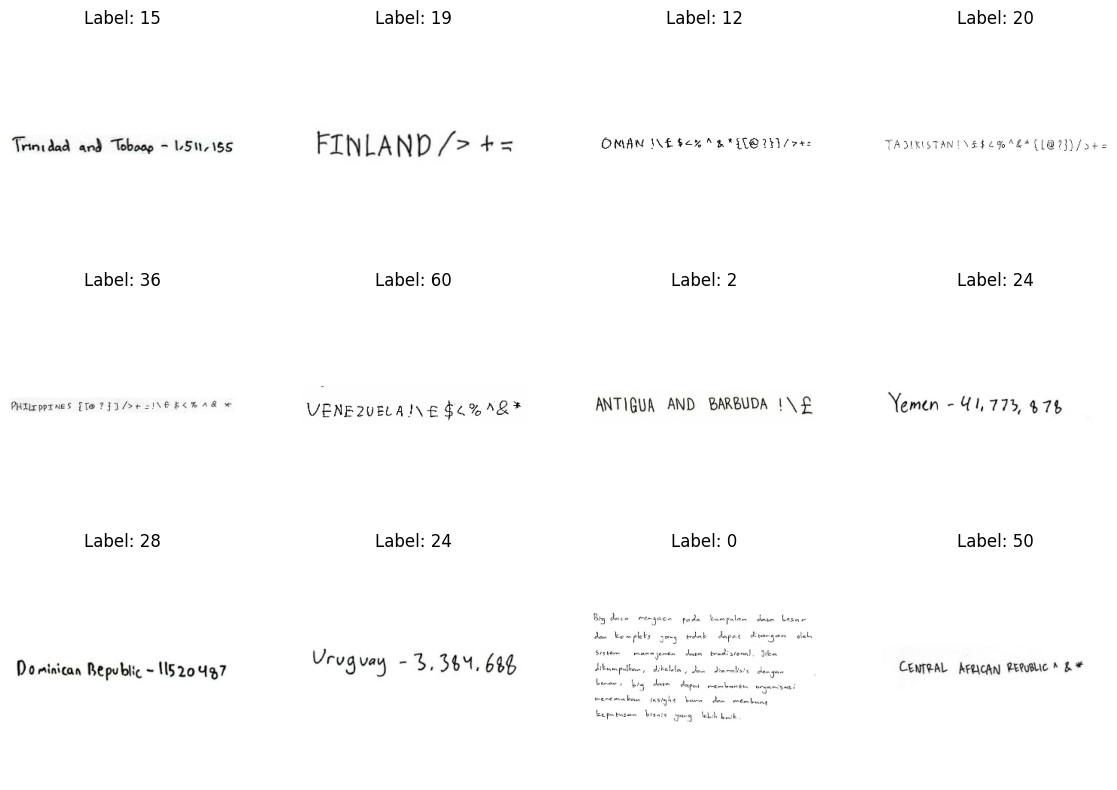

In [ ]:
plt.figure(figsize=(12, 8))

for images, labels in train_70_ds.take(1):
    for i in range(12):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i])
        plt.title(f"Label: {labels[i].numpy()}")
        plt.axis("off")

plt.tight_layout()
plt.show()

#**4. CNN Model Training**

In [ ]:
#Import Layer untuk CNN
from tensorflow.keras import layers, models

**4.1 Build CNN Architecture**

In [ ]:
def build_cnn_model():
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    return model

**4.2 Buat CNN Model for 80:20**

In [ ]:
cnn_model_80 = build_cnn_model()

**4.3 Compile CNN Model**

In [ ]:
loss='sparse_categorical_crossentropy'

In [ ]:
cnn_model_80.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**4.4 Model Summary**

Model CNN baseline dibangun menggunakan beberapa lapisan Convolutional 2D dan MaxPooling 2D untuk mengekstraksi fitur visual dari citra tulisan tangan.

Lapisan GlobalAveragePooling2D: mengurangi jumlah parameter model sehingga proses pelatihan lebih ringan.

Dropout: mengurangi risiko overfitting, sedangkan lapisan output menggunakan aktivasi softmax karena dataset memiliki 64 kelas penulis.

In [ ]:
cnn_model_80.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 299, 299, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 149, 149, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 149, 149, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 74, 74, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 470,656 (1.80 MB)

 Trainable params: 470,656 (1.80 MB)

 Non-trainable params: 0 (0.00 B)

**4.5 Setup Callbacks CNN 80:20**

In [ ]:
callbacks_cnn_80 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(output_dir, 'best_cnn_80_20.keras'),
        monitor='val_accuracy',
        save_best_only=True
    )
]

**4.6 Train CNN 80:20**

In [ ]:
history_cnn_80 = cnn_model_80.fit(
    train_80_ds,
    validation_data=test_20_ds,
    epochs=30,
    callbacks=callbacks_cnn_80
)

Epoch 1/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 1530s 10s/step - accuracy: 0.0113 - loss: 4.1606 - val_accuracy: 0.0156 - val_loss: 4.1589
Epoch 2/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 24s 151ms/step - accuracy: 0.0166 - loss: 4.1125 - val_accuracy: 0.0367 - val_loss: 3.9755
Epoch 3/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 23s 145ms/step - accuracy: 0.0398 - loss: 3.8477 - val_accuracy: 0.0477 - val_loss: 3.6528
Epoch 4/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 23s 143ms/step - accuracy: 0.0566 - loss: 3.6467 - val_accuracy: 0.0664 - val_loss: 3.5623
Epoch 5/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 40s 138ms/step - accuracy: 0.0770 - loss: 3.4706 - val_accuracy: 0.1227 - val_loss: 3.3071
Epoch 6/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 41s 141ms/step - accuracy: 0.0998 - loss: 3.2705 - val_accuracy: 0.1305 - val_loss: 3.1542
Epoch 7/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 41s 143ms/step - accuracy: 0.1262 - loss: 3.1318 - val_accuracy: 0.1914 - val_loss: 3.0039
Epoch 8/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 23s 143ms/step - accuracy: 0.1404 - loss: 3

**4.7 evaluasi final CNN 80:20**

In [ ]:
test_loss_80, test_acc_80 = cnn_model_80.evaluate(test_20_ds)

print(f"Test Loss CNN 80:20: {test_loss_80:.4f}")
print(f"Test Accuracy CNN 80:20: {test_acc_80:.4f}")

40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.5594 - loss: 1.7958
Test Loss CNN 80:20: 1.7958
Test Accuracy CNN 80:20: 0.5594


**4.8 Simpan history training**

In [ ]:
history_cnn_80_df = pd.DataFrame(history_cnn_80.history)
history_cnn_80_df.to_csv(os.path.join(output_dir, 'history_cnn_80_20.csv'), index=False) #riwayat accuracy/loss per epoch

print("History CNN 80:20 berhasil disimpan.")

cnn_model_80.save(os.path.join(output_dir, 'final_cnn_80_20.keras')) #model CNN final yang sudah dilatih

print("Model final CNN 80:20 berhasil disimpan.")

History CNN 80:20 berhasil disimpan.
Model final CNN 80:20 berhasil disimpan.


**4.9 CNN Model Training 70:30**

**Buat model baru untuk 70:30**

In [ ]:
cnn_model_70 = build_cnn_model()

cnn_model_70.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model_70.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 299, 299, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 149, 149, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 149, 149, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 74, 74, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │        16,448 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 470,656 (1.80 MB)

 Trainable params: 470,656 (1.80 MB)

 Non-trainable params: 0 (0.00 B)

**Callbacks CNN 70/30**

In [ ]:
callbacks_cnn_70 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(output_dir, 'best_cnn_70_30.keras'),
        monitor='val_accuracy',
        save_best_only=True
    )
]

**Train CNN 70:30**

In [ ]:
history_cnn_70 = cnn_model_70.fit(
    train_70_ds,
    validation_data=test_30_ds,
    epochs=30,
    callbacks=callbacks_cnn_70
)

Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 29s 168ms/step - accuracy: 0.0167 - loss: 4.1351 - val_accuracy: 0.0370 - val_loss: 4.0258
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 27s 193ms/step - accuracy: 0.0333 - loss: 3.8875 - val_accuracy: 0.0391 - val_loss: 3.7690
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 37s 166ms/step - accuracy: 0.0442 - loss: 3.6954 - val_accuracy: 0.0698 - val_loss: 3.5676
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 27s 191ms/step - accuracy: 0.0576 - loss: 3.6081 - val_accuracy: 0.0755 - val_loss: 3.5005
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 164ms/step - accuracy: 0.0603 - loss: 3.5248 - val_accuracy: 0.0964 - val_loss: 3.4389
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 175ms/step - accuracy: 0.0728 - loss: 3.4657 - val_accuracy: 0.0969 - val_loss: 3.4173
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 180ms/step - accuracy: 0.0750 - loss: 3.4223 - val_accuracy: 0.1146 - val_loss: 3.4786
Epoch 8/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 24s 168ms/step - accuracy: 0.0931 - loss: 3

**Evaluasi model CNN 70/30**

In [ ]:
test_loss_70, test_acc_70 = cnn_model_70.evaluate(test_30_ds)

print(f"Test Loss CNN 70:30: {test_loss_70:.4f}")
print(f"Test Accuracy CNN 70:30: {test_acc_70:.4f}")

60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 135ms/step - accuracy: 0.4969 - loss: 2.0040
Test Loss CNN 70:30: 2.0040
Test Accuracy CNN 70:30: 0.4969


**Hasil waktu komputasi CNN 80/20 dan CNN 70/30**

In [ ]:
cnn_computation_time_df = pd.DataFrame({
    'model': ['CNN', 'CNN'],
    'split': ['80:20', '70:30'],
    'epochs': [30, 30],
    'training_time_seconds': [2335, 808],
    'training_time_minutes': [2335/60, 808/60],
    'evaluation_time_seconds': [5, 8],
    'test_loss': [1.7958, 2.0040],
    'test_accuracy': [0.5594, 0.4969]
})

cnn_computation_time_df.to_csv(
    os.path.join(output_dir, 'cnn_computation_time.csv'),
    index=False
)

cnn_computation_time_df

,model,split,epochs,training_time_seconds,training_time_minutes,evaluation_time_seconds,test_loss,test_accuracy
0,CNN,80:20,30,2335,38.916667,5,1.7958,0.5594
1,CNN,70:30,30,808,13.466667,8,2.0040,0.4969


**Simpan history + model**

In [ ]:
history_cnn_70_df = pd.DataFrame(history_cnn_70.history)
history_cnn_70_df.to_csv(os.path.join(output_dir, 'history_cnn_70_30.csv'), index=False)

cnn_model_70.save(os.path.join(output_dir, 'final_cnn_70_30.keras'))

print("History dan model CNN 70:30 berhasil disimpan.")

History dan model CNN 70:30 berhasil disimpan.


#**5. InceptionV3 Model Training**

In [ ]:
#Import inceptionv3
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras import layers, models
import time

In [ ]:
#build model inceptionv3
layers.Lambda(lambda x: x * 255.0)
layers.Lambda(preprocess_input)

<Lambda name=lambda_1, built=False>

In [ ]:
def build_inception_model():
    base_model = InceptionV3(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    base_model.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = layers.Lambda(lambda x: x * 255.0)(inputs)
    x = layers.Lambda(preprocess_input)(x)

    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    return model

**5.1 Buat model InceptionV3 80:20**

In [ ]:
inception_model_80 = build_inception_model()

inception_model_80.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

inception_model_80.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_3 (Lambda)               │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,343,776 (85.23 MB)

 Trainable params: 540,992 (2.06 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

**5.2 Callbacks InceptionV3 80:20**

In [ ]:
callbacks_inception_80 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(output_dir, 'best_inceptionv3_80_20.keras'),
        monitor='val_accuracy',
        save_best_only=True
    )
]

**5.3 Train InceptionV3 80:20**

In [ ]:
start_time = time.time()

history_inception_80 = inception_model_80.fit(
    train_80_ds,
    validation_data=test_20_ds,
    epochs=30,
    callbacks=callbacks_inception_80
)

end_time = time.time()
training_time_inception_80 = end_time - start_time

print(f"Training Time InceptionV3 80:20: {training_time_inception_80:.2f} seconds")
print(f"Training Time InceptionV3 80:20: {training_time_inception_80/60:.2f} minutes")

Epoch 1/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 2244s 14s/step - accuracy: 0.0641 - loss: 3.9693 - val_accuracy: 0.1414 - val_loss: 3.6530
Epoch 2/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 27s 169ms/step - accuracy: 0.1211 - loss: 3.5792 - val_accuracy: 0.1937 - val_loss: 3.3168
Epoch 3/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 27s 170ms/step - accuracy: 0.1574 - loss: 3.3216 - val_accuracy: 0.2352 - val_loss: 3.0879
Epoch 4/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 40s 161ms/step - accuracy: 0.1967 - loss: 3.1236 - val_accuracy: 0.2789 - val_loss: 2.9054
Epoch 5/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 28s 170ms/step - accuracy: 0.2162 - loss: 2.9894 - val_accuracy: 0.3125 - val_loss: 2.7305
Epoch 6/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 28s 171ms/step - accuracy: 0.2500 - loss: 2.8287 - val_accuracy: 0.3266 - val_loss: 2.6048
Epoch 7/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 28s 171ms/step - accuracy: 0.2695 - loss: 2.7320 - val_accuracy: 0.3805 - val_loss: 2.4988
Epoch 8/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 27s 167ms/step - accuracy: 0.2861 - loss: 2

**5.4 Evaluasi InceptionV3 80:20**

In [ ]:
start_eval_time = time.time()

test_loss_inception_80, test_acc_inception_80 = inception_model_80.evaluate(test_20_ds)

end_eval_time = time.time()
eval_time_inception_80 = end_eval_time - start_eval_time

print(f"Test Loss InceptionV3 80:20: {test_loss_inception_80:.4f}")
print(f"Test Accuracy InceptionV3 80:20: {test_acc_inception_80:.4f}")
print(f"Evaluation Time InceptionV3 80:20: {eval_time_inception_80:.2f} seconds")

40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 243ms/step - accuracy: 0.5594 - loss: 1.6537
Test Loss InceptionV3 80:20: 1.6537
Test Accuracy InceptionV3 80:20: 0.5594
Evaluation Time InceptionV3 80:20: 9.76 seconds


**5.5 Save History + model + waktu**

In [ ]:
history_inception_80_df = pd.DataFrame(history_inception_80.history)
history_inception_80_df.to_csv(
    os.path.join(output_dir, 'history_inceptionv3_80_20.csv'),
    index=False
)

inception_model_80.save(os.path.join(output_dir, 'final_inceptionv3_80_20.keras'))

inception_time_80_df = pd.DataFrame({
    'model': ['InceptionV3'],
    'split': ['80:20'],
    'epochs': [len(history_inception_80.history['loss'])],
    'training_time_seconds': [training_time_inception_80],
    'training_time_minutes': [training_time_inception_80 / 60],
    'evaluation_time_seconds': [eval_time_inception_80],
    'test_loss': [test_loss_inception_80],
    'test_accuracy': [test_acc_inception_80]
})

inception_time_80_df.to_csv(
    os.path.join(output_dir, 'inceptionv3_80_20_result.csv'),
    index=False
)

print("History, model, dan waktu komputasi InceptionV3 80:20 berhasil disimpan.")

History, model, dan waktu komputasi InceptionV3 80:20 berhasil disimpan.


**Fine Tuning InceptionV3 80:20**

In [ ]:
base_model = inception_model_80.get_layer('inception_v3')

base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

In [ ]:
inception_model_80.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#callbacks fine tuning
callbacks_finetune_inception_80 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(output_dir, 'best_finetuned_inceptionv3_80_20.keras'),
        monitor='val_accuracy',
        save_best_only=True
    )
]

In [ ]:
#train fine tuning 10 epoch
start_time = time.time()

history_finetune_inception_80 = inception_model_80.fit(
    train_80_ds,
    validation_data=test_20_ds,
    epochs=10,
    callbacks=callbacks_finetune_inception_80
)

end_time = time.time()
finetune_time_inception_80 = end_time - start_time

print(f"Fine-tuning Time InceptionV3 80:20: {finetune_time_inception_80:.2f} seconds")
print(f"Fine-tuning Time InceptionV3 80:20: {finetune_time_inception_80/60:.2f} minutes")

Epoch 1/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 63s 233ms/step - accuracy: 0.1383 - loss: 8.7300 - val_accuracy: 0.3602 - val_loss: 2.5570
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 35s 217ms/step - accuracy: 0.2744 - loss: 2.9248 - val_accuracy: 0.4414 - val_loss: 2.0729
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 32s 202ms/step - accuracy: 0.3582 - loss: 2.2544 - val_accuracy: 0.4797 - val_loss: 1.8758
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 41s 204ms/step - accuracy: 0.4139 - loss: 2.0317 - val_accuracy: 0.5305 - val_loss: 1.7579
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 33s 202ms/step - accuracy: 0.4422 - loss: 1.8887 - val_accuracy: 0.5398 - val_loss: 1.6789
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 33s 202ms/step - accuracy: 0.4842 - loss: 1.7648 - val_accuracy: 0.5562 - val_loss: 1.6162
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 32s 195ms/step - accuracy: 0.4904 - loss: 1.6861 - val_accuracy: 0.5734 - val_loss: 1.5462
Epoch 8/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 41s 200ms/step - accuracy: 0.5385 - loss: 1

In [ ]:
#eval fine-tuned model
start_eval_time = time.time()

test_loss_finetune_inception_80, test_acc_finetune_inception_80 = inception_model_80.evaluate(test_20_ds)

end_eval_time = time.time()
eval_time_finetune_inception_80 = end_eval_time - start_eval_time

print(f"Test Loss Fine-tuned InceptionV3 80:20: {test_loss_finetune_inception_80:.4f}")
print(f"Test Accuracy Fine-tuned InceptionV3 80:20: {test_acc_finetune_inception_80:.4f}")
print(f"Evaluation Time Fine-tuned InceptionV3 80:20: {eval_time_finetune_inception_80:.2f} seconds")

40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 231ms/step - accuracy: 0.6234 - loss: 1.4113
Test Loss Fine-tuned InceptionV3 80:20: 1.4113
Test Accuracy Fine-tuned InceptionV3 80:20: 0.6234
Evaluation Time Fine-tuned InceptionV3 80:20: 9.27 seconds


In [ ]:
history_finetune_inception_80_df = pd.DataFrame(history_finetune_inception_80.history)
history_finetune_inception_80_df.to_csv(
    os.path.join(output_dir, 'history_finetuned_inceptionv3_80_20.csv'),
    index=False
)

inception_model_80.save(
    os.path.join(output_dir, 'final_finetuned_inceptionv3_80_20.keras')
)

finetune_inception_80_result_df = pd.DataFrame({
    'model': ['Fine-tuned InceptionV3'],
    'split': ['80:20'],
    'epochs': [len(history_finetune_inception_80.history['loss'])],
    'training_time_seconds': [finetune_time_inception_80],
    'training_time_minutes': [finetune_time_inception_80 / 60],
    'evaluation_time_seconds': [eval_time_finetune_inception_80],
    'test_loss': [test_loss_finetune_inception_80],
    'test_accuracy': [test_acc_finetune_inception_80]
})

finetune_inception_80_result_df.to_csv(
    os.path.join(output_dir, 'finetuned_inceptionv3_80_20_result.csv'),
    index=False
)

print("Fine-tuned InceptionV3 80:20 berhasil disimpan.")

Fine-tuned InceptionV3 80:20 berhasil disimpan.


In [ ]:
print(inception_model_80 is not None)

True


##**Extra Fine-tuning InceptionV3 80:20**

In [ ]:
base_model_80 = inception_model_80.get_layer('inception_v3')

base_model_80.trainable = True

for layer in base_model_80.layers[:-50]:
    layer.trainable = False

In [ ]:
inception_model_80.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.000005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
callbacks_extra_finetune_inception_80 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=4,
        mode='max',
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(output_dir, 'best_extra_finetuned_inceptionv3_80_20.keras'),
        monitor='val_accuracy',
        mode='max',
        save_best_only=True
    )
]

In [ ]:
start_time = time.time()

history_extra_finetune_inception_80 = inception_model_80.fit(
    train_80_ds,
    validation_data=test_20_ds,
    initial_epoch=10,
    epochs=20,
    callbacks=callbacks_extra_finetune_inception_80
)

end_time = time.time()
extra_finetune_time_inception_80 = end_time - start_time

print(f"Extra Fine-tuning Time InceptionV3 80:20: {extra_finetune_time_inception_80:.2f} seconds")
print(f"Extra Fine-tuning Time InceptionV3 80:20: {extra_finetune_time_inception_80/60:.2f} minutes")

Epoch 11/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 60s 228ms/step - accuracy: 0.5908 - loss: 1.3541 - val_accuracy: 0.6281 - val_loss: 1.3773
Epoch 12/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 32s 195ms/step - accuracy: 0.6029 - loss: 1.3115 - val_accuracy: 0.6297 - val_loss: 1.3555
Epoch 13/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 32s 200ms/step - accuracy: 0.6148 - loss: 1.2741 - val_accuracy: 0.6328 - val_loss: 1.3426
Epoch 14/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 32s 199ms/step - accuracy: 0.6287 - loss: 1.2551 - val_accuracy: 0.6398 - val_loss: 1.3243
Epoch 15/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 34s 208ms/step - accuracy: 0.6369 - loss: 1.1997 - val_accuracy: 0.6477 - val_loss: 1.3091
Epoch 16/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 33s 206ms/step - accuracy: 0.6340 - loss: 1.1962 - val_accuracy: 0.6508 - val_loss: 1.2903
Epoch 17/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 38s 188ms/step - accuracy: 0.6570 - loss: 1.1290 - val_accuracy: 0.6500 - val_loss: 1.2955
Epoch 18/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 29s 183ms/step - accuracy: 0.6619 -

**evaluasi best extra finetuned model - InceptionV3 80/20**

In [ ]:
start_eval_time = time.time()

test_loss_extra_finetune_inception_80, test_acc_extra_finetune_inception_80 = inception_model_80.evaluate(test_20_ds)

end_eval_time = time.time()
eval_time_extra_finetune_inception_80 = end_eval_time - start_eval_time

print(f"Test Loss Extra Fine-tuned InceptionV3 80:20: {test_loss_extra_finetune_inception_80:.4f}")
print(f"Test Accuracy Extra Fine-tuned InceptionV3 80:20: {test_acc_extra_finetune_inception_80:.4f}")
print(f"Evaluation Time Extra Fine-tuned InceptionV3 80:20: {eval_time_extra_finetune_inception_80:.2f} seconds")

40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - accuracy: 0.6687 - loss: 1.2659
Test Loss Extra Fine-tuned InceptionV3 80:20: 1.2659
Test Accuracy Extra Fine-tuned InceptionV3 80:20: 0.6687
Evaluation Time Extra Fine-tuned InceptionV3 80:20: 10.25 seconds


In [ ]:
history_extra_finetune_inception_80_df = pd.DataFrame(history_extra_finetune_inception_80.history)
history_extra_finetune_inception_80_df.to_csv(
    os.path.join(output_dir, 'history_extra_finetuned_inceptionv3_80_20.csv'),
    index=False
)

inception_model_80.save(
    os.path.join(output_dir, 'final_extra_finetuned_inceptionv3_80_20.keras')
)

extra_finetune_inception_80_result_df = pd.DataFrame({
    'model': ['Extra Fine-tuned InceptionV3'],
    'split': ['80:20'],
    'previous_finetune_epochs': [10],
    'extra_finetune_epochs': [len(history_extra_finetune_inception_80.history['loss'])],
    'extra_training_time_seconds': [extra_finetune_time_inception_80],
    'extra_training_time_minutes': [extra_finetune_time_inception_80 / 60],
    'evaluation_time_seconds': [eval_time_extra_finetune_inception_80],
    'test_loss': [test_loss_extra_finetune_inception_80],
    'test_accuracy': [test_acc_extra_finetune_inception_80]
})

extra_finetune_inception_80_result_df.to_csv(
    os.path.join(output_dir, 'extra_finetuned_inceptionv3_80_20_result.csv'),
    index=False
)

print("Extra fine-tuned InceptionV3 80:20 berhasil disimpan.")

Extra fine-tuned InceptionV3 80:20 berhasil disimpan.


##**InceptionV3 70:30**

**5.6 Build InceptionV3 70:30**

In [ ]:
inception_model_70 = build_inception_model()

inception_model_70.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

inception_model_70.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_4 (Lambda)               │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_5 (Lambda)               │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        16,448 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,343,776 (85.23 MB)

 Trainable params: 540,992 (2.06 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

**5.7 Callbacks Frozen InceptionV3 70:30**

In [ ]:
callbacks_inception_70 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(output_dir, 'best_inceptionv3_70_30.keras'),
        monitor='val_accuracy',
        save_best_only=True
    )
]

**5.8 Train Frozen InceptionV3 70:30**

In [ ]:
start_time = time.time()

history_inception_70 = inception_model_70.fit(
    train_70_ds,
    validation_data=test_30_ds,
    epochs=10,
    callbacks=callbacks_inception_70
)

end_time = time.time()
training_time_inception_70 = end_time - start_time

print(f"Training Time InceptionV3 70:30: {training_time_inception_70:.2f} seconds")
print(f"Training Time InceptionV3 70:30: {training_time_inception_70/60:.2f} minutes")

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 49s 243ms/step - accuracy: 0.0545 - loss: 4.0158 - val_accuracy: 0.1109 - val_loss: 3.7641
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 28s 202ms/step - accuracy: 0.1033 - loss: 3.6888 - val_accuracy: 0.1615 - val_loss: 3.4279
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 28s 198ms/step - accuracy: 0.1417 - loss: 3.4301 - val_accuracy: 0.2026 - val_loss: 3.2197
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 27s 196ms/step - accuracy: 0.1703 - loss: 3.2478 - val_accuracy: 0.2557 - val_loss: 3.0504
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 29s 204ms/step - accuracy: 0.2076 - loss: 3.0882 - val_accuracy: 0.2844 - val_loss: 2.8837
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 29s 206ms/step - accuracy: 0.2167 - loss: 2.9795 - val_accuracy: 0.3120 - val_loss: 2.7713
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 28s 201ms/step - accuracy: 0.2458 - loss: 2.8617 - val_accuracy: 0.3302 - val_loss: 2.6656
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 28s 200ms/step - accuracy: 0.2647 - loss: 2

**Fine Tuning InceptionV3 70:30**

In [ ]:
base_model_70 = inception_model_70.get_layer('inception_v3')

base_model_70.trainable = True

for layer in base_model_70.layers[:-50]:
    layer.trainable = False

In [ ]:
inception_model_70.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#callbacks finetuning
callbacks_finetune_inception_70 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(output_dir, 'best_finetuned_inceptionv3_70_30.keras'),
        monitor='val_accuracy',
        save_best_only=True
    )
]

**Train Fine-tuned InceptionV3 70:30**

In [ ]:
start_time = time.time()

history_finetune_inception_70 = inception_model_70.fit(
    train_70_ds,
    validation_data=test_30_ds,
    epochs=10,
    callbacks=callbacks_finetune_inception_70
)

end_time = time.time()
finetune_time_inception_70 = end_time - start_time

print(f"Fine-tuning Time InceptionV3 70:30: {finetune_time_inception_70:.2f} seconds")
print(f"Fine-tuning Time InceptionV3 70:30: {finetune_time_inception_70/60:.2f} minutes")

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 61s 258ms/step - accuracy: 0.1230 - loss: 4.7257 - val_accuracy: 0.2844 - val_loss: 2.7386
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 230ms/step - accuracy: 0.2313 - loss: 2.9485 - val_accuracy: 0.3406 - val_loss: 2.4919
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 34s 244ms/step - accuracy: 0.2864 - loss: 2.6536 - val_accuracy: 0.3776 - val_loss: 2.3546
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 32s 228ms/step - accuracy: 0.3179 - loss: 2.4628 - val_accuracy: 0.4062 - val_loss: 2.2586
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 236ms/step - accuracy: 0.3408 - loss: 2.3478 - val_accuracy: 0.4177 - val_loss: 2.1921
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 232ms/step - accuracy: 0.3629 - loss: 2.2617 - val_accuracy: 0.4469 - val_loss: 2.1030
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 35s 246ms/step - accuracy: 0.3891 - loss: 2.1722 - val_accuracy: 0.4719 - val_loss: 2.0341
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 38s 225ms/step - accuracy: 0.4038 - loss: 2

In [ ]:
#Evaluasi fine tuned inceptionv3 70/30
start_eval_time = time.time()

test_loss_finetune_inception_70, test_acc_finetune_inception_70 = inception_model_70.evaluate(test_30_ds)

end_eval_time = time.time()
eval_time_finetune_inception_70 = end_eval_time - start_eval_time

print(f"Test Loss Fine-tuned InceptionV3 70:30: {test_loss_finetune_inception_70:.4f}")
print(f"Test Accuracy Fine-tuned InceptionV3 70:30: {test_acc_finetune_inception_70:.4f}")
print(f"Evaluation Time Fine-tuned InceptionV3 70:30: {eval_time_finetune_inception_70:.2f} seconds")

60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 176ms/step - accuracy: 0.4990 - loss: 1.9030
Test Loss Fine-tuned InceptionV3 70:30: 1.9030
Test Accuracy Fine-tuned InceptionV3 70:30: 0.4990
Evaluation Time Fine-tuned InceptionV3 70:30: 20.50 seconds


In [ ]:
#Save hasil inceptionV3 70/30
history_inception_70_df = pd.DataFrame(history_inception_70.history)
history_inception_70_df.to_csv(
    os.path.join(output_dir, 'history_inceptionv3_70_30.csv'),
    index=False
)

history_finetune_inception_70_df = pd.DataFrame(history_finetune_inception_70.history)
history_finetune_inception_70_df.to_csv(
    os.path.join(output_dir, 'history_finetuned_inceptionv3_70_30.csv'),
    index=False
)

inception_model_70.save(
    os.path.join(output_dir, 'final_finetuned_inceptionv3_70_30.keras')
)

finetune_inception_70_result_df = pd.DataFrame({
    'model': ['Fine-tuned InceptionV3'],
    'split': ['70:30'],
    'frozen_epochs': [len(history_inception_70.history['loss'])],
    'finetune_epochs': [len(history_finetune_inception_70.history['loss'])],
    'frozen_training_time_seconds': [training_time_inception_70],
    'finetune_training_time_seconds': [finetune_time_inception_70],
    'total_training_time_seconds': [training_time_inception_70 + finetune_time_inception_70],
    'total_training_time_minutes': [(training_time_inception_70 + finetune_time_inception_70) / 60],
    'evaluation_time_seconds': [eval_time_finetune_inception_70],
    'test_loss': [test_loss_finetune_inception_70],
    'test_accuracy': [test_acc_finetune_inception_70]
})

finetune_inception_70_result_df.to_csv(
    os.path.join(output_dir, 'finetuned_inceptionv3_70_30_result.csv'),
    index=False
)

print("Fine-tuned InceptionV3 70:30 berhasil disimpan.")

Fine-tuned InceptionV3 70:30 berhasil disimpan.


###**Extra Fine-tuning InceptionV3 70:30**

In [ ]:
print(inception_model_70 is not None)

True


In [ ]:
base_model_70 = inception_model_70.get_layer('inception_v3')

base_model_70.trainable = True

for layer in base_model_70.layers[:-50]:
    layer.trainable = False

In [ ]:
inception_model_70.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.000005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#callbacks extra fine-tuning 70:30
callbacks_extra_finetune_inception_70 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=4,
        mode='max',
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(output_dir, 'best_extra_finetuned_inceptionv3_70_30.keras'),
        monitor='val_accuracy',
        mode='max',
        save_best_only=True
    )
]

In [ ]:
start_time = time.time()

history_extra_finetune_inception_70 = inception_model_70.fit(
    train_70_ds,
    validation_data=test_30_ds,
    initial_epoch=10,
    epochs=20,
    callbacks=callbacks_extra_finetune_inception_70
)

end_time = time.time()
extra_finetune_time_inception_70 = end_time - start_time

print(f"Extra Fine-tuning Time InceptionV3 70:30: {extra_finetune_time_inception_70:.2f} seconds")
print(f"Extra Fine-tuning Time InceptionV3 70:30: {extra_finetune_time_inception_70/60:.2f} minutes")

Epoch 11/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 62s 251ms/step - accuracy: 0.4627 - loss: 1.8718 - val_accuracy: 0.5141 - val_loss: 1.8479
Epoch 12/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 29s 205ms/step - accuracy: 0.4725 - loss: 1.8347 - val_accuracy: 0.5240 - val_loss: 1.8278
Epoch 13/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 32s 226ms/step - accuracy: 0.4877 - loss: 1.7799 - val_accuracy: 0.5271 - val_loss: 1.8029
Epoch 14/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 29s 209ms/step - accuracy: 0.4938 - loss: 1.7497 - val_accuracy: 0.5266 - val_loss: 1.7881
Epoch 15/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 29s 210ms/step - accuracy: 0.4868 - loss: 1.7403 - val_accuracy: 0.5339 - val_loss: 1.7710
Epoch 16/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 39s 194ms/step - accuracy: 0.5121 - loss: 1.6834 - val_accuracy: 0.5328 - val_loss: 1.7573
Epoch 17/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 28s 203ms/step - accuracy: 0.5165 - loss: 1.6532 - val_accuracy: 0.5365 - val_loss: 1.7322
Epoch 18/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 31s 217ms/step - accuracy: 0.5330 -

In [ ]:
#evaluasi final 70/30
start_eval_time = time.time()

test_loss_extra_finetune_inception_70, test_acc_extra_finetune_inception_70 = inception_model_70.evaluate(test_30_ds)

end_eval_time = time.time()
eval_time_extra_finetune_inception_70 = end_eval_time - start_eval_time

print(f"Test Loss Extra Fine-tuned InceptionV3 70:30: {test_loss_extra_finetune_inception_70:.4f}")
print(f"Test Accuracy Extra Fine-tuned InceptionV3 70:30: {test_acc_extra_finetune_inception_70:.4f}")
print(f"Evaluation Time Extra Fine-tuned InceptionV3 70:30: {eval_time_extra_finetune_inception_70:.2f} seconds")

60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 242ms/step - accuracy: 0.5479 - loss: 1.6929
Test Loss Extra Fine-tuned InceptionV3 70:30: 1.6929
Test Accuracy Extra Fine-tuned InceptionV3 70:30: 0.5479
Evaluation Time Extra Fine-tuned InceptionV3 70:30: 14.58 seconds


In [ ]:
#save hasil 70/30
history_extra_finetune_inception_70_df = pd.DataFrame(history_extra_finetune_inception_70.history)
history_extra_finetune_inception_70_df.to_csv(
    os.path.join(output_dir, 'history_extra_finetuned_inceptionv3_70_30.csv'),
    index=False
)

inception_model_70.save(
    os.path.join(output_dir, 'final_extra_finetuned_inceptionv3_70_30.keras')
)

extra_finetune_inception_70_result_df = pd.DataFrame({
    'model': ['Extra Fine-tuned InceptionV3'],
    'split': ['70:30'],
    'previous_finetune_epochs': [10],
    'extra_finetune_epochs': [len(history_extra_finetune_inception_70.history['loss'])],
    'extra_training_time_seconds': [extra_finetune_time_inception_70],
    'extra_training_time_minutes': [extra_finetune_time_inception_70 / 60],
    'evaluation_time_seconds': [eval_time_extra_finetune_inception_70],
    'test_loss': [test_loss_extra_finetune_inception_70],
    'test_accuracy': [test_acc_extra_finetune_inception_70]
})

extra_finetune_inception_70_result_df.to_csv(
    os.path.join(output_dir, 'extra_finetuned_inceptionv3_70_30_result.csv'),
    index=False
)

print("Extra fine-tuned InceptionV3 70:30 berhasil disimpan.")

Extra fine-tuned InceptionV3 70:30 berhasil disimpan.


#**Tabel Ringkasan CNN & InceptionV3**

In [ ]:
final_results_df = pd.DataFrame({
    'Model': [
        'CNN',
        'CNN',
        'Fine-tuned InceptionV3',
        'Fine-tuned InceptionV3'
    ],
    'Split': [
        '80:20',
        '70:30',
        '80:20',
        '70:30'
    ],
    'Test Loss': [
        1.7958,
        2.0040,
        1.2659,
        1.6929
    ],
    'Test Accuracy': [
        0.5594,
        0.4969,
        0.6687,
        0.5479
    ],
    'Test Accuracy (%)': [
        55.94,
        49.69,
        66.87,
        54.79
    ],
    'Evaluation Time (seconds)': [
        5.00,
        8.00,
        10.25,
        14.58
    ]
})

final_results_df.to_csv(
    os.path.join(output_dir, 'final_result_summary.csv'),
    index=False
)

final_results_df

,Model,Split,Test Loss,Test Accuracy,Test Accuracy (%),Evaluation Time (seconds)
0,CNN,80:20,1.7958,0.5594,55.94,5.00
1,CNN,70:30,2.0040,0.4969,49.69,8.00
2,Fine-tuned InceptionV3,80:20,1.2659,0.6687,66.87,10.25
3,Fine-tuned InceptionV3,70:30,1.6929,0.5479,54.79,14.58


##**Stratified 3-Fold Cross Validation**

In [ ]:
from sklearn.model_selection import StratifiedKFold
import tensorflow as tf
import pandas as pd
import numpy as np
import os
import time

N_SPLITS = 3
KFOLD_EPOCHS_CNN = 30
KFOLD_FROZEN_EPOCHS_INCEPTION = 10
KFOLD_FINETUNE_EPOCHS_INCEPTION = 10
skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

kfold_results = []

In [ ]:
kfold_cnn_results = []

In [ ]:
from tensorflow.keras import layers, models

def build_cnn_model():
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    return model

KFold CNN

In [ ]:
for fold, (train_idx, val_idx) in enumerate(skf.split(final_df, final_df['label']), start=1):
    print(f"\n===== CNN K-Fold {fold}/{N_SPLITS} =====")

    tf.keras.backend.clear_session()

    train_fold_df = final_df.iloc[train_idx].reset_index(drop=True)
    val_fold_df = final_df.iloc[val_idx].reset_index(drop=True)

    train_fold_ds = create_tf_dataset(train_fold_df, batch_size=BATCH_SIZE, shuffle=True)
    val_fold_ds = create_tf_dataset(val_fold_df, batch_size=BATCH_SIZE, shuffle=False)

    cnn_kfold_model = build_cnn_model()

    cnn_kfold_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks_cnn_kfold = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )
    ]

    start_time = time.time()

    history_cnn_kfold = cnn_kfold_model.fit(
        train_fold_ds,
        validation_data=val_fold_ds,
        epochs=KFOLD_EPOCHS_CNN,
        callbacks=callbacks_cnn_kfold,
        verbose=1
    )

    end_time = time.time()
    training_time = end_time - start_time

    val_loss, val_accuracy = cnn_kfold_model.evaluate(val_fold_ds, verbose=1)

    kfold_cnn_results.append({
        'model': 'CNN',
        'fold': fold,
        'val_loss': val_loss,
        'val_accuracy': val_accuracy,
        'training_time_seconds': training_time,
        'epochs_run': len(history_cnn_kfold.history['loss'])
    })

    print(f"CNN K-Fold {fold} Accuracy: {val_accuracy:.4f}")
    print(f"CNN K-Fold {fold} Loss: {val_loss:.4f}")


===== CNN K-Fold 1/3 =====
Epoch 1/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 31s 202ms/step - accuracy: 0.0145 - loss: 4.1467 - val_accuracy: 0.0305 - val_loss: 4.0549
Epoch 2/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 23s 174ms/step - accuracy: 0.0307 - loss: 3.9542 - val_accuracy: 0.0375 - val_loss: 3.7436
Epoch 3/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 27s 199ms/step - accuracy: 0.0415 - loss: 3.7227 - val_accuracy: 0.0464 - val_loss: 3.5919
Epoch 4/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 26s 192ms/step - accuracy: 0.0532 - loss: 3.6116 - val_accuracy: 0.0651 - val_loss: 3.4704
Epoch 5/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 25s 184ms/step - accuracy: 0.0563 - loss: 3.5465 - val_accuracy: 0.0759 - val_loss: 3.4053
Epoch 6/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 27s 200ms/step - accuracy: 0.0598 - loss: 3.4848 - val_accuracy: 0.0937 - val_loss: 3.3519
Epoch 7/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 27s 202ms/step - accuracy: 0.0764 - loss: 3.4124 - val_accuracy: 0.1162 - val_loss: 3.2899
Epoch 8/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 27s 198ms/step 

In [ ]:
kfold_cnn_results_df = pd.DataFrame({
    'model': ['CNN', 'CNN', 'CNN'],
    'fold': [1, 2, 3],
    'val_loss': [1.6930, 1.7666, 2.0293],
    'val_accuracy': [0.5084, 0.4791, 0.4449],
    'val_accuracy_percent': [50.84, 47.91, 44.49],
    'epochs_run': [30, 30, 30]
})

kfold_cnn_results_df.to_csv(
    os.path.join(output_dir, 'kfold_cnn_3fold_final.csv'),
    index=False
)

kfold_cnn_results_df

,model,fold,val_loss,val_accuracy,val_accuracy_percent,epochs_run
0,CNN,1,1.6930,0.5084,50.84,30
1,CNN,2,1.7666,0.4791,47.91,30
2,CNN,3,2.0293,0.4449,44.49,30


In [ ]:
cnn_kfold_summary_df = pd.DataFrame({
    'model': ['CNN'],
    'kfold': ['3-Fold'],
    'mean_accuracy': [kfold_cnn_results_df['val_accuracy'].mean()],
    'std_accuracy': [kfold_cnn_results_df['val_accuracy'].std()],
    'mean_accuracy_percent': [kfold_cnn_results_df['val_accuracy_percent'].mean()],
    'std_accuracy_percent': [kfold_cnn_results_df['val_accuracy_percent'].std()],
    'mean_loss': [kfold_cnn_results_df['val_loss'].mean()],
    'std_loss': [kfold_cnn_results_df['val_loss'].std()]
})

cnn_kfold_summary_df.to_csv(
    os.path.join(output_dir, 'kfold_cnn_3fold_summary.csv'),
    index=False
)

cnn_kfold_summary_df

,model,kfold,mean_accuracy,std_accuracy,mean_accuracy_percent,std_accuracy_percent,mean_loss,std_loss
0,CNN,3-Fold,0.477467,0.031781,47.746667,3.178149,1.829633,0.176789


**KFold InceptionV3**

In [ ]:
from sklearn.model_selection import StratifiedKFold

In [ ]:
N_SPLITS = 3
KFOLD_FROZEN_EPOCHS_INCEPTION = 10
KFOLD_FINETUNE_EPOCHS_INCEPTION = 10

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

kfold_inception_results_path = os.path.join(output_dir, 'kfold_inceptionv3_3fold_final.csv')

if os.path.exists(kfold_inception_results_path):
    kfold_inception_results_df = pd.read_csv(kfold_inception_results_path)
    completed_folds = set(kfold_inception_results_df['fold'].tolist())
    kfold_inception_results = kfold_inception_results_df.to_dict('records')
else:
    completed_folds = set()
    kfold_inception_results = []

print("Completed folds:", completed_folds)

Completed folds: set()


**KFold InceptionV3, K=3**

In [ ]:
import tensorflow as tf

print("GPU devices:", tf.config.list_physical_devices('GPU'))

GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
for fold, (train_idx, val_idx) in enumerate(skf.split(final_df, final_df['label']), start=1):
    if fold in completed_folds:
        print(f"\n===== InceptionV3 Fold {fold}/{N_SPLITS} sudah selesai, skip =====")
        continue

    print(f"\n===== InceptionV3 Fold {fold}/{N_SPLITS} =====")

    tf.keras.backend.clear_session()

    train_fold_df = final_df.iloc[train_idx].reset_index(drop=True)
    val_fold_df = final_df.iloc[val_idx].reset_index(drop=True)

    train_fold_ds = create_tf_dataset(train_fold_df, batch_size=BATCH_SIZE, shuffle=True)
    val_fold_ds = create_tf_dataset(val_fold_df, batch_size=BATCH_SIZE, shuffle=False)

    inception_kfold_model = build_inception_model()

    inception_kfold_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks_frozen = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ]

    frozen_start_time = time.time()

    history_frozen = inception_kfold_model.fit(
        train_fold_ds,
        validation_data=val_fold_ds,
        epochs=KFOLD_FROZEN_EPOCHS_INCEPTION,
        callbacks=callbacks_frozen,
        verbose=1
    )

    frozen_end_time = time.time()
    frozen_training_time = frozen_end_time - frozen_start_time

    base_model = inception_kfold_model.get_layer('inception_v3')
    base_model.trainable = True

    for layer in base_model.layers[:-50]:
        layer.trainable = False

    inception_kfold_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.000005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks_finetune = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=4,
            mode='max',
            restore_best_weights=True
        )
    ]

    finetune_start_time = time.time()

    history_finetune = inception_kfold_model.fit(
        train_fold_ds,
        validation_data=val_fold_ds,
        epochs=KFOLD_FINETUNE_EPOCHS_INCEPTION,
        callbacks=callbacks_finetune,
        verbose=1
    )

    finetune_end_time = time.time()
    finetune_training_time = finetune_end_time - finetune_start_time

    eval_start_time = time.time()
    val_loss, val_accuracy = inception_kfold_model.evaluate(val_fold_ds, verbose=1)
    eval_end_time = time.time()
    evaluation_time = eval_end_time - eval_start_time

    fold_result = {
        'model': 'Fine-tuned InceptionV3',
        'fold': fold,
        'val_loss': val_loss,
        'val_accuracy': val_accuracy,
        'val_accuracy_percent': val_accuracy * 100,
        'frozen_epochs_run': len(history_frozen.history['loss']),
        'finetune_epochs_run': len(history_finetune.history['loss']),
        'frozen_training_time_seconds': frozen_training_time,
        'finetune_training_time_seconds': finetune_training_time,
        'total_training_time_seconds': frozen_training_time + finetune_training_time,
        'evaluation_time_seconds': evaluation_time
    }

    kfold_inception_results.append(fold_result)

    pd.DataFrame(kfold_inception_results).to_csv(
        kfold_inception_results_path,
        index=False
    )

    print(f"InceptionV3 Fold {fold} Accuracy: {val_accuracy:.4f}")
    print(f"InceptionV3 Fold {fold} Loss: {val_loss:.4f}")
    print(f"Fold {fold} saved.")


===== InceptionV3 Fold 1/3 sudah selesai, skip =====

===== InceptionV3 Fold 2/3 =====
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 2323s 17s/step - accuracy: 0.0569 - loss: 4.0167 - val_accuracy: 0.1116 - val_loss: 3.7650
Epoch 2/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 28s 211ms/step - accuracy: 0.1080 - loss: 3.6840 - val_accuracy: 0.1669 - val_loss: 3.4693
Epoch 3/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 40s 205ms/step - accuracy: 0.1385 - loss: 3.4709 - val_accuracy: 0.2077 - val_loss: 3.2375
Epoch 4/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 28s 211ms/step - accuracy: 0.1666 - loss: 3.2961 - val_accuracy: 0.2363 - val_loss: 3.0643
Epoch 5/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 27s 205ms/step - accuracy: 0.1985 - loss: 3.1345 - val_accuracy: 0.2668 - val_loss: 2.9285
Epoch 6/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 27s 202ms/step - accuracy: 0.2151 - loss: 3.0154 - val_accuracy: 0.2982 - val_loss: 2.8147
Epoch 7/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 27s 204ms/step - accuracy: 0.2332 -

In [ ]:
kfold_inception_results_path = os.path.join(output_dir, 'kfold_inceptionv3_3fold_final.csv')

if os.path.exists(kfold_inception_results_path):
    kfold_inception_results_df = pd.read_csv(kfold_inception_results_path)
    completed_folds = set(kfold_inception_results_df['fold'].tolist())
    kfold_inception_results = kfold_inception_results_df.to_dict('records')
else:
    completed_folds = set()
    kfold_inception_results = []

print("Completed folds:", completed_folds)

Completed folds: {1}


In [ ]:
kfold_inception_results_df = pd.read_csv(kfold_inception_results_path)

inception_kfold_summary_df = pd.DataFrame({
    'model': ['Fine-tuned InceptionV3'],
    'kfold': ['3-Fold'],
    'mean_accuracy': [kfold_inception_results_df['val_accuracy'].mean()],
    'std_accuracy': [kfold_inception_results_df['val_accuracy'].std()],
    'mean_accuracy_percent': [kfold_inception_results_df['val_accuracy_percent'].mean()],
    'std_accuracy_percent': [kfold_inception_results_df['val_accuracy_percent'].std()],
    'mean_loss': [kfold_inception_results_df['val_loss'].mean()],
    'std_loss': [kfold_inception_results_df['val_loss'].std()]
})

inception_kfold_summary_df.to_csv(
    os.path.join(output_dir, 'kfold_inceptionv3_3fold_consistent_10_10_summary.csv'),
    index=False
)

inception_kfold_summary_df

,model,kfold,mean_accuracy,std_accuracy,mean_accuracy_percent,std_accuracy_percent,mean_loss,std_loss
0,Fine-tuned InceptionV3,3-Fold,0.428124,0.015911,42.812358,1.591099,2.140613,0.033928


**Hasil KFold CNN dan InceptionV3**

In [ ]:
cnn_kfold_summary_df = pd.read_csv(
    os.path.join(output_dir, 'kfold_cnn_3fold_summary.csv')
)

kfold_summary_all_df = pd.concat(
    [cnn_kfold_summary_df, inception_kfold_summary_df],
    ignore_index=True
)

kfold_summary_all_df.to_csv(
    os.path.join(output_dir, 'kfold_3fold_summary_all_models.csv'),
    index=False
)

kfold_summary_all_df

,model,kfold,mean_accuracy,std_accuracy,mean_accuracy_percent,std_accuracy_percent,mean_loss,std_loss
0,CNN,3-Fold,0.477467,0.031781,47.746667,3.178149,1.829633,0.176789
1,Fine-tuned InceptionV3,3-Fold,0.428124,0.015911,42.812358,1.591099,2.140613,0.033928


In [ ]:
important_files = [
    'final_handwriting_dataset.csv',
    'train_80.csv',
    'test_20.csv',
    'train_70.csv',
    'test_30.csv',
    'history_cnn_80_20.csv',
    'history_cnn_70_30.csv',
    'history_extra_finetuned_inceptionv3_80_20.csv',
    'history_extra_finetuned_inceptionv3_70_30.csv',
    'final_extra_finetuned_inceptionv3_80_20.keras',
    'final_extra_finetuned_inceptionv3_70_30.keras',
    'kfold_cnn_3fold_summary.csv',
    'kfold_cnn_3fold_final.csv'
]

for file in important_files:
    path = os.path.join(output_dir, file)
    print(file, "ADA" if os.path.exists(path) else "BELUM ADA")

final_handwriting_dataset.csv ADA
train_80.csv ADA
test_20.csv ADA
train_70.csv ADA
test_30.csv ADA
history_cnn_80_20.csv ADA
history_cnn_70_30.csv ADA
history_extra_finetuned_inceptionv3_80_20.csv ADA
history_extra_finetuned_inceptionv3_70_30.csv ADA
final_extra_finetuned_inceptionv3_80_20.keras ADA
final_extra_finetuned_inceptionv3_70_30.keras ADA
kfold_cnn_3fold_summary.csv ADA
kfold_cnn_3fold_final.csv ADA


**Final Results Summary**

In [ ]:
final_results_df = pd.DataFrame({
    'Model': [
        'CNN',
        'CNN',
        'Fine-tuned InceptionV3',
        'Fine-tuned InceptionV3'
    ],
    'Evaluation Scenario': [
        '80:20 Split',
        '70:30 Split',
        '80:20 Split',
        '70:30 Split'
    ],
    'Test Loss': [
        1.7958,
        2.0040,
        1.2659,
        1.6929
    ],
    'Test Accuracy': [
        0.5594,
        0.4969,
        0.6687,
        0.5479
    ],
    'Test Accuracy (%)': [
        55.94,
        49.69,
        66.87,
        54.79
    ]
})

final_results_df.to_csv(
    os.path.join(output_dir, 'final_result_summary.csv'),
    index=False
)

final_results_df

,Model,Evaluation Scenario,Test Loss,Test Accuracy,Test Accuracy (%)
0,CNN,80:20 Split,1.7958,0.5594,55.94
1,CNN,70:30 Split,2.0040,0.4969,49.69
2,Fine-tuned InceptionV3,80:20 Split,1.2659,0.6687,66.87
3,Fine-tuned InceptionV3,70:30 Split,1.6929,0.5479,54.79


**Status Eksperimen CNN dan InceptionV3**

In [ ]:
experiment_status_df = pd.DataFrame({
    'Experiment': [
        'CNN 80:20',
        'CNN 70:30',
        'Extra Fine-tuned InceptionV3 80:20',
        'Extra Fine-tuned InceptionV3 70:30',
        'CNN 3-Fold Cross Validation',
        'InceptionV3 3-Fold Cross Validation'
    ],
    'Status': [
        'Completed',
        'Completed',
        'Completed',
        'Completed',
        'Completed',
        'Completed'
    ],
    'Main Result': [
        'Accuracy 55.94%',
        'Accuracy 49.69%',
        'Accuracy 66.87%',
        'Accuracy 54.79%',
        'Mean accuracy 47.75% ± 3.18%',
        'Mean accuracy 42.81% ± 1.59%'
    ],
    'Notes': [
        'Baseline CNN dengan skenario pembagian data 80:20',
        'Baseline CNN dengan skenario pembagian data 70:30',
        'Model terbaik pada eksperimen utama',
        'InceptionV3 pada skenario pembagian data 70:30',
        'Stratified 3-Fold Cross Validation, 30 epoch per fold',
        'Stratified 3-Fold Cross Validation, frozen 10 epoch dan fine-tuning 10 epoch per fold'
    ]
})

experiment_status_df.to_csv(
    os.path.join(output_dir, 'experiment_status_summary.csv'),
    index=False
)

experiment_status_df

,Experiment,Status,Main Result,Notes
0,CNN 80:20,Completed,Accuracy 55.94%,Baseline CNN dengan skenario pembagian data 80:20
1,CNN 70:30,Completed,Accuracy 49.69%,Baseline CNN dengan skenario pembagian data 70:30
2,Extra Fine-tuned InceptionV3 80:20,Completed,Accuracy 66.87%,Model terbaik pada eksperimen utama
3,Extra Fine-tuned InceptionV3 70:30,Completed,Accuracy 54.79%,InceptionV3 pada skenario pembagian data 70:30
4,CNN 3-Fold Cross Validation,Completed,Mean accuracy 47.75% ± 3.18%,"Stratified 3-Fold Cross Validation, 30 epoch p..."
5,InceptionV3 3-Fold Cross Validation,Completed,Mean accuracy 42.81% ± 1.59%,"Stratified 3-Fold Cross Validation, frozen 10 ..."


In [ ]:
cnn_kfold_path = os.path.join(output_dir, 'kfold_cnn_3fold_final.csv')

inception_kfold_possible_paths = [
    os.path.join(output_dir, 'kfold_inceptionv3_3fold_consistent_10_10.csv'),
    os.path.join(output_dir, 'kfold_inceptionv3_3fold_final.csv')
]

inception_kfold_path = None
for path in inception_kfold_possible_paths:
    if os.path.exists(path):
        inception_kfold_path = path
        break

print("CNN K-Fold path:", cnn_kfold_path)
print("InceptionV3 K-Fold path:", inception_kfold_path)

if not os.path.exists(cnn_kfold_path):
    raise FileNotFoundError("File kfold_cnn_3fold_final.csv belum ada.")

if inception_kfold_path is None:
    raise FileNotFoundError("File K-Fold InceptionV3 belum ditemukan.")

CNN K-Fold path: /content/drive/MyDrive/ML_UAS/kfold_cnn_3fold_final.csv
InceptionV3 K-Fold path: /content/drive/MyDrive/ML_UAS/kfold_inceptionv3_3fold_consistent_10_10.csv


In [ ]:
cnn_kfold_results_df = pd.read_csv(cnn_kfold_path)
inception_kfold_results_df = pd.read_csv(inception_kfold_path)

print("CNN K-Fold:")
display(cnn_kfold_results_df)

print("InceptionV3 K-Fold:")
display(inception_kfold_results_df)

CNN K-Fold:


,model,fold,val_loss,val_accuracy,val_accuracy_percent,epochs_run
0,CNN,1,1.6930,0.5084,50.84,30
1,CNN,2,1.7666,0.4791,47.91,30
2,CNN,3,2.0293,0.4449,44.49,30


InceptionV3 K-Fold:


,model,fold,val_loss,val_accuracy,val_accuracy_percent,frozen_epochs_run,finetune_epochs_run,frozen_training_time_seconds,finetune_training_time_seconds,total_training_time_seconds,evaluation_time_seconds
0,Fine-tuned InceptionV3,1,2.101480,0.437207,43.720713,10,10,1608.890773,355.757733,1964.648505,9.193374
1,Fine-tuned InceptionV3,2,2.158569,0.437412,43.741208,10,10,2599.972129,370.356206,2970.328335,9.625942
2,Fine-tuned InceptionV3,3,2.161789,0.409752,40.975153,10,10,373.791538,376.908701,750.700238,9.496860


In [ ]:
cnn_kfold_summary_df = pd.DataFrame({
    'model': ['CNN'],
    'kfold': ['3-Fold'],
    'mean_accuracy': [cnn_kfold_results_df['val_accuracy'].mean()],
    'std_accuracy': [cnn_kfold_results_df['val_accuracy'].std()],
    'mean_accuracy_percent': [cnn_kfold_results_df['val_accuracy_percent'].mean()],
    'std_accuracy_percent': [cnn_kfold_results_df['val_accuracy_percent'].std()],
    'mean_loss': [cnn_kfold_results_df['val_loss'].mean()],
    'std_loss': [cnn_kfold_results_df['val_loss'].std()]
})

inception_kfold_summary_df = pd.DataFrame({
    'model': ['Fine-tuned InceptionV3'],
    'kfold': ['3-Fold'],
    'mean_accuracy': [inception_kfold_results_df['val_accuracy'].mean()],
    'std_accuracy': [inception_kfold_results_df['val_accuracy'].std()],
    'mean_accuracy_percent': [inception_kfold_results_df['val_accuracy_percent'].mean()],
    'std_accuracy_percent': [inception_kfold_results_df['val_accuracy_percent'].std()],
    'mean_loss': [inception_kfold_results_df['val_loss'].mean()],
    'std_loss': [inception_kfold_results_df['val_loss'].std()]
})

cnn_kfold_summary_df.to_csv(
    os.path.join(output_dir, 'kfold_cnn_3fold_summary.csv'),
    index=False
)

inception_kfold_summary_df.to_csv(
    os.path.join(output_dir, 'kfold_inceptionv3_3fold_consistent_10_10_summary.csv'),
    index=False
)

kfold_summary_all_df = pd.concat(
    [cnn_kfold_summary_df, inception_kfold_summary_df],
    ignore_index=True
)

kfold_summary_all_df.to_csv(
    os.path.join(output_dir, 'kfold_3fold_summary_all_models.csv'),
    index=False
)

kfold_summary_all_df

,model,kfold,mean_accuracy,std_accuracy,mean_accuracy_percent,std_accuracy_percent,mean_loss,std_loss
0,CNN,3-Fold,0.477467,0.031781,47.746667,3.178149,1.829633,0.176789
1,Fine-tuned InceptionV3,3-Fold,0.428124,0.015911,42.812358,1.591099,2.140613,0.033928


#**Grafik akurasi hasil split**

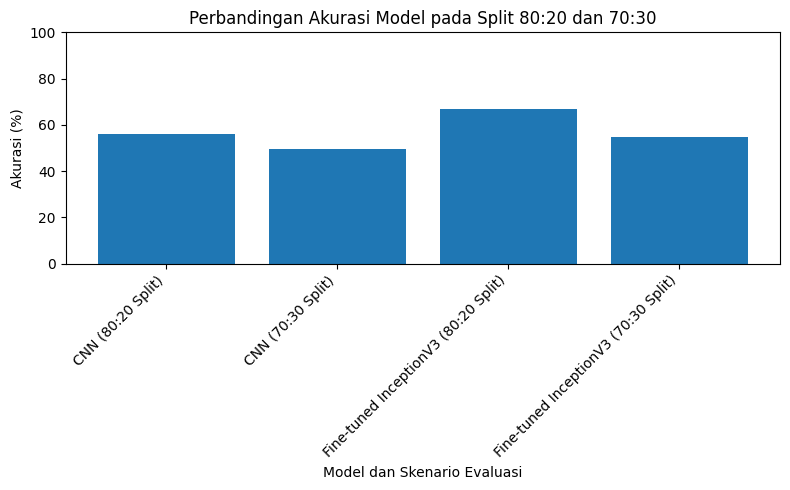

Saved: /content/drive/MyDrive/ML_UAS/grafik_akurasi_split.png


In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    final_results_df['Model'] + ' (' + final_results_df['Evaluation Scenario'] + ')',
    final_results_df['Test Accuracy (%)']
)

plt.title('Perbandingan Akurasi Model pada Split 80:20 dan 70:30')
plt.xlabel('Model dan Skenario Evaluasi')
plt.ylabel('Akurasi (%)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)
plt.tight_layout()

accuracy_chart_path = os.path.join(output_dir, 'grafik_akurasi_split.png')
plt.savefig(accuracy_chart_path, dpi=300, bbox_inches='tight')
plt.show()

print("Saved:", accuracy_chart_path)

#**Grafik loss hasil split**

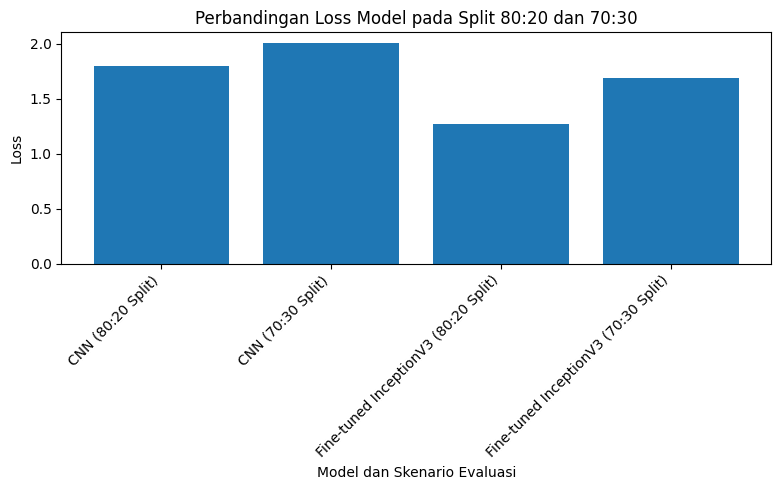

Saved: /content/drive/MyDrive/ML_UAS/grafik_loss_split.png


In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    final_results_df['Model'] + ' (' + final_results_df['Evaluation Scenario'] + ')',
    final_results_df['Test Loss']
)

plt.title('Perbandingan Loss Model pada Split 80:20 dan 70:30')
plt.xlabel('Model dan Skenario Evaluasi')
plt.ylabel('Loss')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

loss_chart_path = os.path.join(output_dir, 'grafik_loss_split.png')
plt.savefig(loss_chart_path, dpi=300, bbox_inches='tight')
plt.show()

print("Saved:", loss_chart_path)

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

output_dir = '/content/drive/MyDrive/ML_UAS'

history_files = [
    'history_cnn_80_20.csv',
    'history_cnn_70_30.csv',
    'history_inceptionv3_80_20.csv',
    'history_finetuned_inceptionv3_80_20.csv',
    'history_extra_finetuned_inceptionv3_80_20.csv',
    'history_inceptionv3_70_30.csv',
    'history_finetuned_inceptionv3_70_30.csv',
    'history_extra_finetuned_inceptionv3_70_30.csv'
]

for file in history_files:
    path = os.path.join(output_dir, file)
    print(file, "ADA" if os.path.exists(path) else "BELUM ADA")

history_cnn_80_20.csv ADA
history_cnn_70_30.csv ADA
history_inceptionv3_80_20.csv ADA
history_finetuned_inceptionv3_80_20.csv ADA
history_extra_finetuned_inceptionv3_80_20.csv ADA
history_inceptionv3_70_30.csv ADA
history_finetuned_inceptionv3_70_30.csv ADA
history_extra_finetuned_inceptionv3_70_30.csv ADA


**Grafik CNN 80/20**

Training & Accuracy

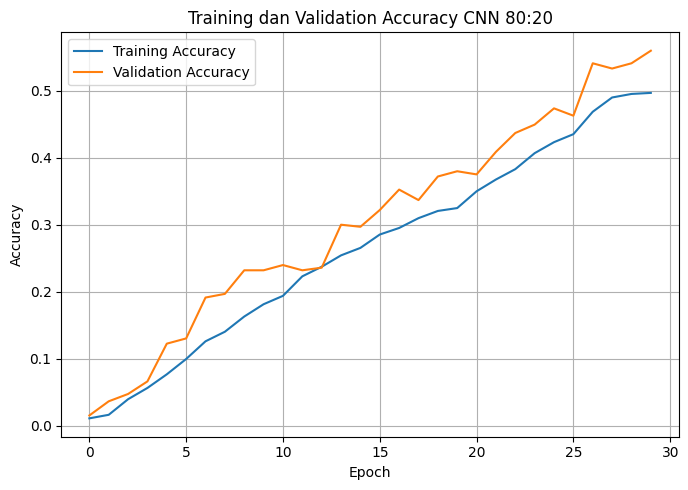

Saved: /content/drive/MyDrive/ML_UAS/curve_accuracy_cnn_80_20.png


In [ ]:
history_cnn_80_df = pd.read_csv(
    os.path.join(output_dir, 'history_cnn_80_20.csv')
)

plt.figure(figsize=(7, 5))

plt.plot(history_cnn_80_df['accuracy'], label='Training Accuracy')
plt.plot(history_cnn_80_df['val_accuracy'], label='Validation Accuracy')

plt.title('Training dan Validation Accuracy CNN 80:20')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()

cnn_80_accuracy_curve_path = os.path.join(output_dir, 'curve_accuracy_cnn_80_20.png')
plt.savefig(cnn_80_accuracy_curve_path, dpi=300, bbox_inches='tight')
plt.show()

print("Saved:", cnn_80_accuracy_curve_path)

**Grafik CNN 80:20**

Training & Validation LOSS

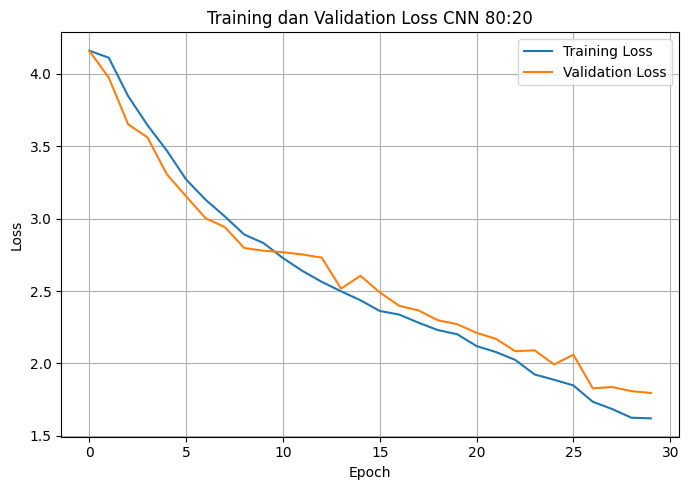

Saved: /content/drive/MyDrive/ML_UAS/curve_loss_cnn_80_20.png


In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(history_cnn_80_df['loss'], label='Training Loss')
plt.plot(history_cnn_80_df['val_loss'], label='Validation Loss')

plt.title('Training dan Validation Loss CNN 80:20')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()

cnn_80_loss_curve_path = os.path.join(output_dir, 'curve_loss_cnn_80_20.png')
plt.savefig(cnn_80_loss_curve_path, dpi=300, bbox_inches='tight')
plt.show()

print("Saved:", cnn_80_loss_curve_path)

**Gabung History InceptionV3 80:20 - 16 Juni 2026**

In [ ]:
history_inception_80_df = pd.read_csv(
    os.path.join(output_dir, 'history_inceptionv3_80_20.csv')
)

history_finetuned_inception_80_df = pd.read_csv(
    os.path.join(output_dir, 'history_finetuned_inceptionv3_80_20.csv')
)

history_extra_finetuned_inception_80_df = pd.read_csv(
    os.path.join(output_dir, 'history_extra_finetuned_inceptionv3_80_20.csv')
)

history_inception_80_df['stage'] = 'Frozen'
history_finetuned_inception_80_df['stage'] = 'Fine-tuning'
history_extra_finetuned_inception_80_df['stage'] = 'Extra fine-tuning'

combined_inception_80_df = pd.concat(
    [
        history_inception_80_df,
        history_finetuned_inception_80_df,
        history_extra_finetuned_inception_80_df
    ],
    ignore_index=True
)

combined_inception_80_df['epoch'] = range(1, len(combined_inception_80_df) + 1)

combined_inception_80_df.to_csv(
    os.path.join(output_dir, 'history_combined_inceptionv3_80_20.csv'),
    index=False
)

combined_inception_80_df

,accuracy,loss,val_accuracy,val_loss,stage,epoch
0,0.064062,3.969313,0.141406,3.652962,Frozen,1
1,0.121094,3.579234,0.193750,3.316844,Frozen,2
2,0.157422,3.321578,0.235156,3.087859,Frozen,3
3,0.196680,3.123567,0.278906,2.905445,Frozen,4
4,0.216211,2.989435,0.312500,2.730521,Frozen,5
5,0.250000,2.828731,0.326562,2.604843,Frozen,6
6,0.269531,2.731969,0.380469,2.498776,Frozen,7
7,0.286133,2.660901,0.406250,2.401792,Frozen,8
8,0.312305,2.542151,0.385156,2.353824,Frozen,9
9,0.325977,2.489529,0.424219,2.239685,Frozen,10


**Grafik Line InceptionV3 80:20**

Training & Validation Accuracy

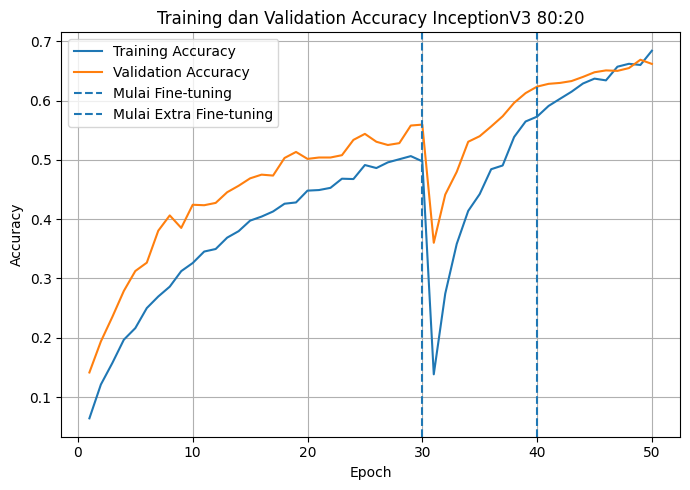

Saved: /content/drive/MyDrive/ML_UAS/curve_accuracy_inceptionv3_80_20.png


In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(
    combined_inception_80_df['epoch'],
    combined_inception_80_df['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    combined_inception_80_df['epoch'],
    combined_inception_80_df['val_accuracy'],
    label='Validation Accuracy'
)

plt.axvline(x=len(history_inception_80_df), linestyle='--', label='Mulai Fine-tuning')
plt.axvline(
    x=len(history_inception_80_df) + len(history_finetuned_inception_80_df),
    linestyle='--',
    label='Mulai Extra Fine-tuning'
)

plt.title('Training dan Validation Accuracy InceptionV3 80:20')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()

inception_80_accuracy_curve_path = os.path.join(output_dir, 'curve_accuracy_inceptionv3_80_20.png')
plt.savefig(inception_80_accuracy_curve_path, dpi=300, bbox_inches='tight')
plt.show()

print("Saved:", inception_80_accuracy_curve_path)

**Grafik Line InceptionV3 80:20**

Training & Validation LOSS

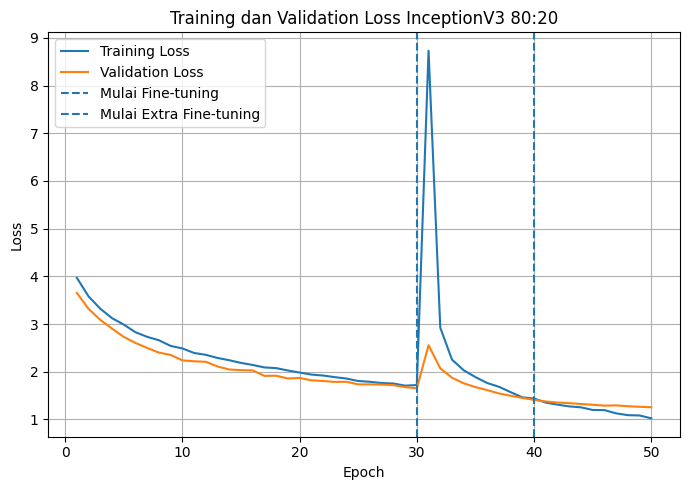

Saved: /content/drive/MyDrive/ML_UAS/curve_loss_inceptionv3_80_20.png


In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(
    combined_inception_80_df['epoch'],
    combined_inception_80_df['loss'],
    label='Training Loss'
)

plt.plot(
    combined_inception_80_df['epoch'],
    combined_inception_80_df['val_loss'],
    label='Validation Loss'
)

plt.axvline(x=len(history_inception_80_df), linestyle='--', label='Mulai Fine-tuning')
plt.axvline(
    x=len(history_inception_80_df) + len(history_finetuned_inception_80_df),
    linestyle='--',
    label='Mulai Extra Fine-tuning'
)

plt.title('Training dan Validation Loss InceptionV3 80:20')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()

inception_80_loss_curve_path = os.path.join(output_dir, 'curve_loss_inceptionv3_80_20.png')
plt.savefig(inception_80_loss_curve_path, dpi=300, bbox_inches='tight')
plt.show()

print("Saved:", inception_80_loss_curve_path)

In [ ]:
from tensorflow.keras.models import load_model

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import load_model
from tensorflow.keras.applications.inception_v3 import preprocess_input
from sklearn.metrics import confusion_matrix, classification_report

output_dir = '/content/drive/MyDrive/ML_UAS'

IMG_SIZE = 299
BATCH_SIZE = 32
NUM_CLASSES = 64

In [ ]:
best_model_path = os.path.join(
    output_dir,
    'final_extra_finetuned_inceptionv3_80_20.keras'
)

best_model = load_model(
    best_model_path,
    custom_objects={'preprocess_input': preprocess_input},
    safe_mode=False,
    compile=False
)

best_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_3 (Lambda)               │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,343,776 (85.23 MB)

 Trainable params: 7,714,304 (29.43 MB)

 Non-trainable params: 14,629,472 (55.81 MB)

**prediksi test set**

In [ ]:
y_true = test_20_df['label'].values

y_pred_prob = best_model.predict(test_20_ds)
y_pred = np.argmax(y_pred_prob, axis=1)

print("jumlah data test:", len(y_true))
print("jumlah prediksi:", len(y_pred))

40/40 ━━━━━━━━━━━━━━━━━━━━ 281s 6s/step
jumlah data test: 1280
jumlah prediksi: 1280


#**CONFUSION MATRIX InceptionV3 80/20**

In [ ]:
cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(cm)
cm_df.to_csv(
    os.path.join(output_dir, 'confusion_matrix_inceptionv3_80_20.csv'),
    index=False
)

cm_df

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,15,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,13,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,14,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,0,11,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,7,0,0,0,3,0,...,0,0,0,0,1,0,1,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,12,0,0,0,0
60,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,16,2,0,0
61,1,2,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,12,0,0
62,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,17,0


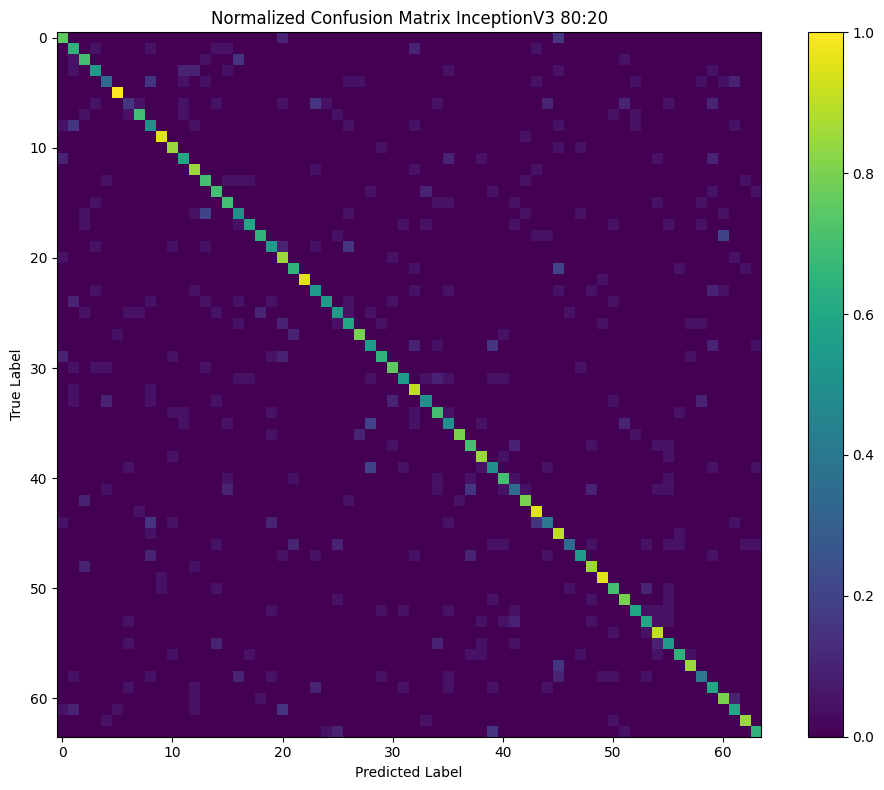

Saved: /content/drive/MyDrive/ML_UAS/confusion_matrix_inceptionv3_80_20.png


In [ ]:
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)
cm_normalized = np.nan_to_num(cm_normalized)

plt.figure(figsize=(10, 8))
plt.imshow(cm_normalized, interpolation='nearest')
plt.title('Normalized Confusion Matrix InceptionV3 80:20')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.colorbar()
plt.tight_layout()

cm_path = os.path.join(output_dir, 'confusion_matrix_inceptionv3_80_20.png')
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
plt.show()

print("Saved:", cm_path)

17 Juni 2026, cek files .keras

In [ ]:
model_files = [f for f in os.listdir(output_dir) if f.endswith('.keras')]
model_files

['best_cnn_80_20.keras',
 'final_cnn_80_20.keras',
 'best_cnn_70_30.keras',
 'final_cnn_70_30.keras',
 'best_inceptionv3_80_20.keras',
 'final_inceptionv3_80_20.keras',
 'best_finetuned_inceptionv3_80_20.keras',
 'final_finetuned_inceptionv3_80_20.keras',
 'best_inceptionv3_70_30.keras',
 'best_finetuned_inceptionv3_70_30.keras',
 'final_finetuned_inceptionv3_70_30.keras',
 'best_extra_finetuned_inceptionv3_80_20.keras',
 'final_extra_finetuned_inceptionv3_80_20.keras',
 'best_extra_finetuned_inceptionv3_70_30.keras',
 'final_extra_finetuned_inceptionv3_70_30.keras']

In [ ]:
#Function generate confusion matrix
def generate_confusion_matrix(model_path, test_df, test_ds, model_name, save_prefix):
    print(f"\n=== Processing: {model_name} ===")
    print("Model path:", model_path)

    model = load_model(
        model_path,
        custom_objects={'preprocess_input': preprocess_input},
        safe_mode=False,
        compile=False
    )

    y_true = test_df['label'].values

    y_pred_prob = model.predict(test_ds)
    y_pred = np.argmax(y_pred_prob, axis=1)

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES))

    total_data = cm.sum()
    correct = np.trace(cm)
    wrong = total_data - correct
    acc = correct / total_data

    print("Total data:", total_data)
    print("Prediksi benar:", correct)
    print("Prediksi salah:", wrong)
    print("Accuracy:", acc)
    print("Accuracy (%):", acc * 100)

    #save raw confusion matrix
    cm_csv_path = os.path.join(output_dir, f'confusion_matrix_{save_prefix}.csv')
    pd.DataFrame(cm).to_csv(cm_csv_path, index=False)

    #save normalized confusion matrix
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    plt.figure(figsize=(10, 8))
    plt.imshow(cm_norm, interpolation='nearest')
    plt.title(f'Normalized Confusion Matrix {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.colorbar()
    plt.tight_layout()

    cm_png_path = os.path.join(output_dir, f'confusion_matrix_{save_prefix}.png')
    plt.savefig(cm_png_path, dpi=300, bbox_inches='tight')
    plt.show()

    #save classification report juga sekalian
    report_dict = classification_report(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report_dict).transpose()
    report_csv_path = os.path.join(output_dir, f'classification_report_{save_prefix}.csv')
    report_df.to_csv(report_csv_path)

    return {
        'model': model_name,
        'total_data': total_data,
        'correct': correct,
        'wrong': wrong,
        'accuracy': acc,
        'cm_csv': cm_csv_path,
        'cm_png': cm_png_path,
        'report_csv': report_csv_path
    }


=== Processing: CNN 80:20 ===
Model path: /content/drive/MyDrive/ML_UAS/final_cnn_80_20.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step
Total data: 1280
Prediksi benar: 716
Prediksi salah: 564
Accuracy: 0.559375
Accuracy (%): 55.93749999999999


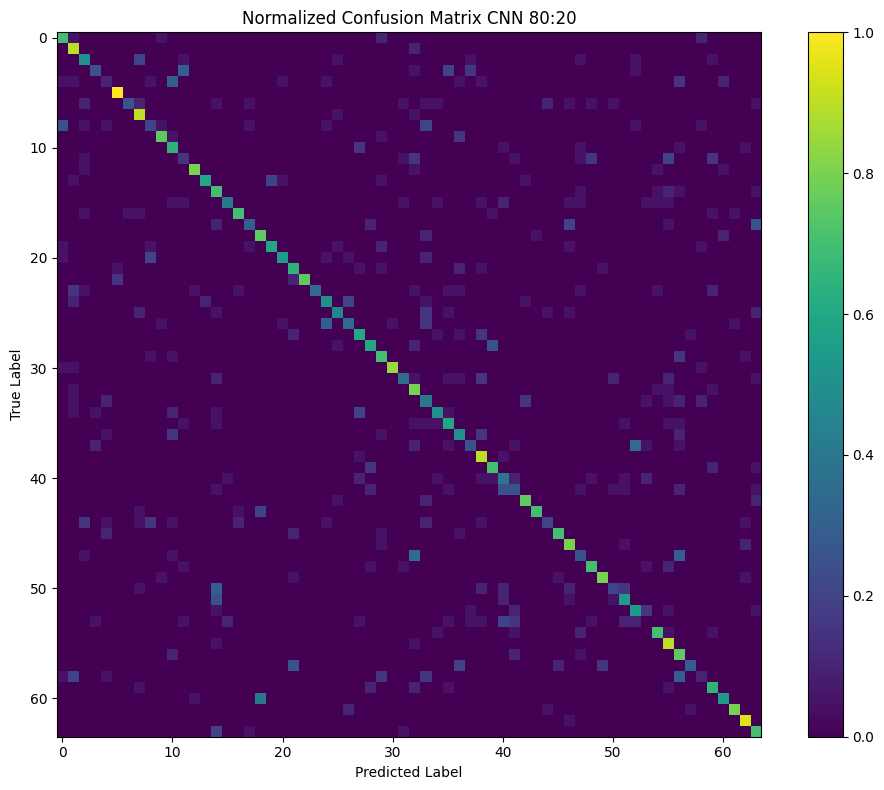


=== Processing: CNN 70:30 ===
Model path: /content/drive/MyDrive/ML_UAS/final_cnn_70_30.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step
Total data: 1920
Prediksi benar: 954
Prediksi salah: 966
Accuracy: 0.496875
Accuracy (%): 49.6875


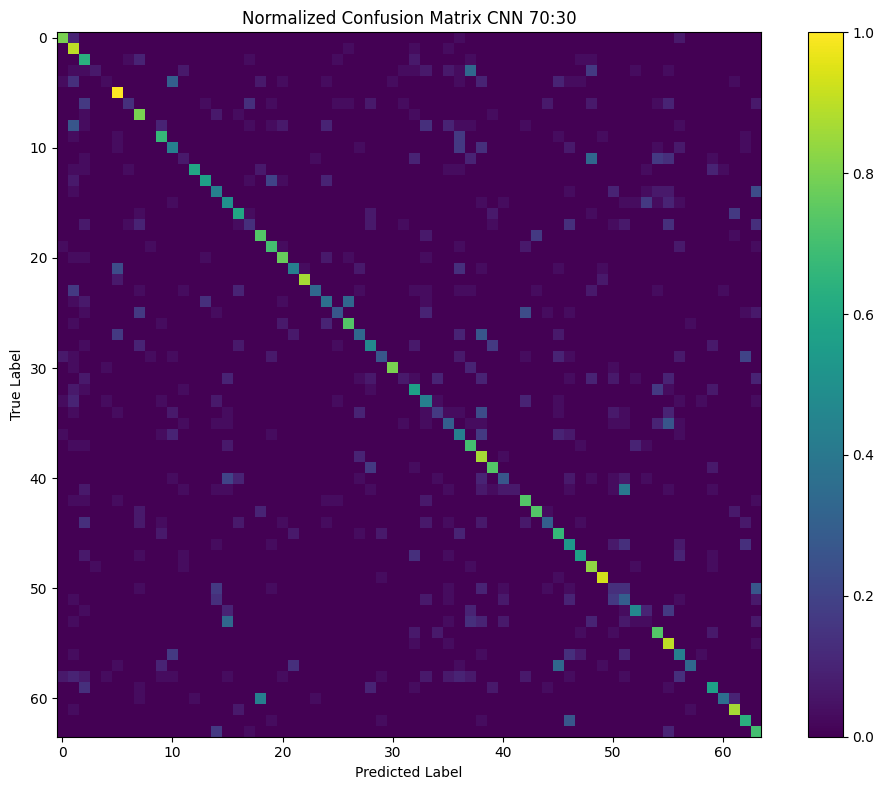


=== Processing: Fine-tuned InceptionV3 80:20 ===
Model path: /content/drive/MyDrive/ML_UAS/final_extra_finetuned_inceptionv3_80_20.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 153ms/step
Total data: 1280
Prediksi benar: 856
Prediksi salah: 424
Accuracy: 0.66875
Accuracy (%): 66.875


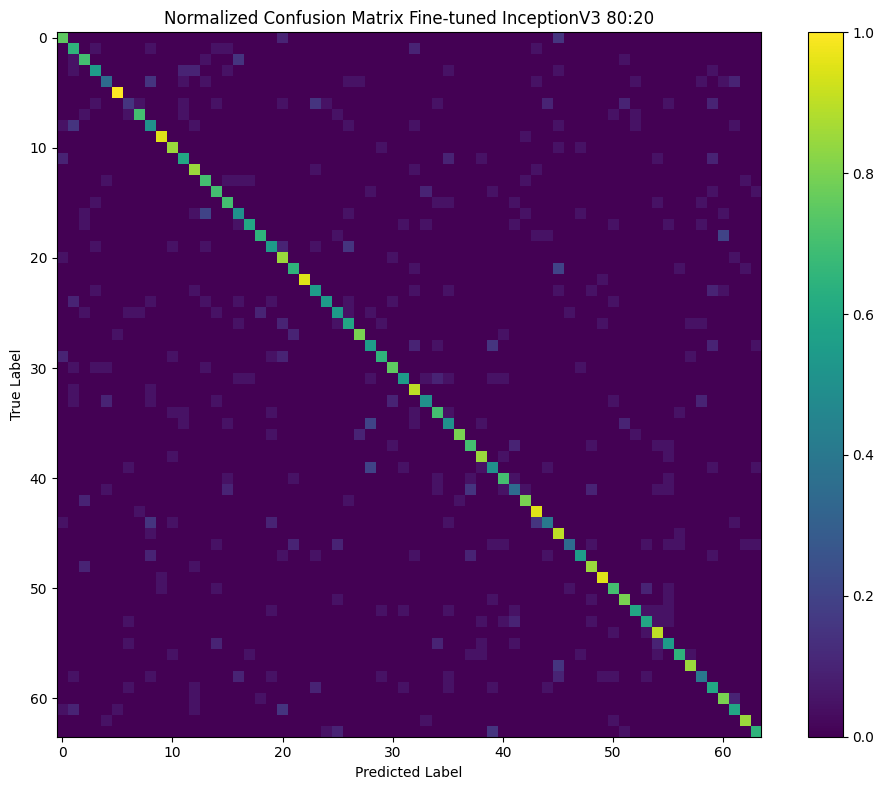


=== Processing: Fine-tuned InceptionV3 70:30 ===
Model path: /content/drive/MyDrive/ML_UAS/final_extra_finetuned_inceptionv3_70_30.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 16s 136ms/step
Total data: 1920
Prediksi benar: 1052
Prediksi salah: 868
Accuracy: 0.5479166666666667
Accuracy (%): 54.79166666666667


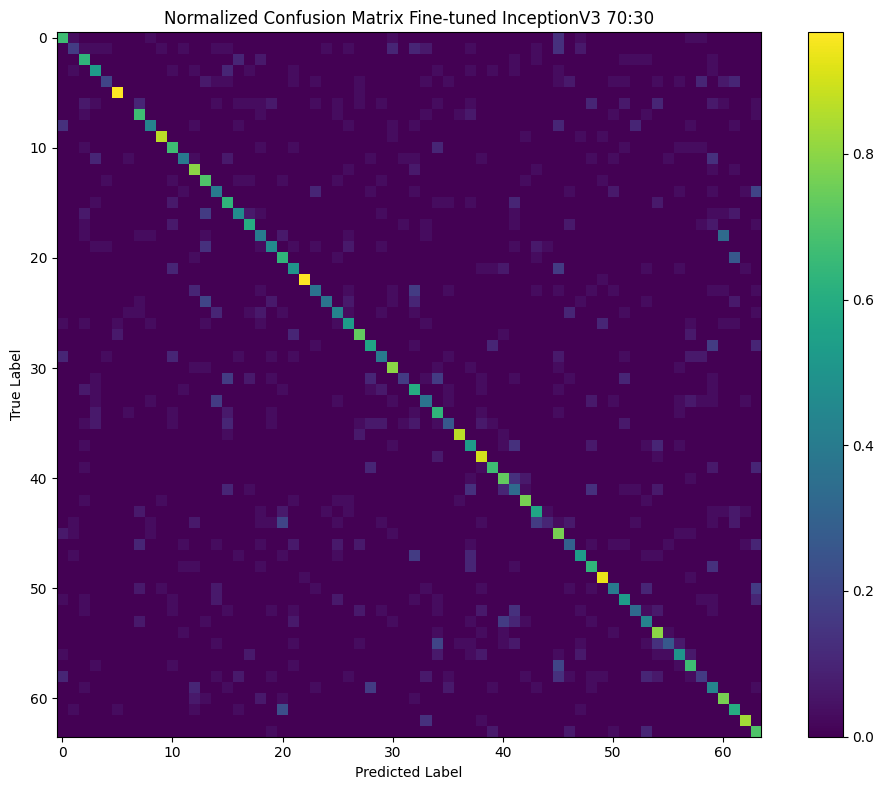

,model,total_data,correct,wrong,accuracy,cm_csv,cm_png,report_csv
0,CNN 80:20,1280,716,564,0.559375,/content/drive/MyDrive/ML_UAS/confusion_matrix...,/content/drive/MyDrive/ML_UAS/confusion_matrix...,/content/drive/MyDrive/ML_UAS/classification_r...
1,CNN 70:30,1920,954,966,0.496875,/content/drive/MyDrive/ML_UAS/confusion_matrix...,/content/drive/MyDrive/ML_UAS/confusion_matrix...,/content/drive/MyDrive/ML_UAS/classification_r...
2,Fine-tuned InceptionV3 80:20,1280,856,424,0.668750,/content/drive/MyDrive/ML_UAS/confusion_matrix...,/content/drive/MyDrive/ML_UAS/confusion_matrix...,/content/drive/MyDrive/ML_UAS/classification_r...
3,Fine-tuned InceptionV3 70:30,1920,1052,868,0.547917,/content/drive/MyDrive/ML_UAS/confusion_matrix...,/content/drive/MyDrive/ML_UAS/confusion_matrix...,/content/drive/MyDrive/ML_UAS/classification_r...


In [ ]:
models_to_evaluate = [
    {
        'model_name': 'CNN 80:20',
        'model_path': os.path.join(output_dir, 'final_cnn_80_20.keras'),
        'test_df': test_20_df,
        'test_ds': test_20_ds,
        'save_prefix': 'cnn_80_20'
    },
    {
        'model_name': 'CNN 70:30',
        'model_path': os.path.join(output_dir, 'final_cnn_70_30.keras'),
        'test_df': test_30_df,
        'test_ds': test_30_ds,
        'save_prefix': 'cnn_70_30'
    },
    {
        'model_name': 'Fine-tuned InceptionV3 80:20',
        'model_path': os.path.join(output_dir, 'final_extra_finetuned_inceptionv3_80_20.keras'),
        'test_df': test_20_df,
        'test_ds': test_20_ds,
        'save_prefix': 'inceptionv3_80_20'
    },
    {
        'model_name': 'Fine-tuned InceptionV3 70:30',
        'model_path': os.path.join(output_dir, 'final_extra_finetuned_inceptionv3_70_30.keras'),
        'test_df': test_30_df,
        'test_ds': test_30_ds,
        'save_prefix': 'inceptionv3_70_30'
    }
]

results = []

for item in models_to_evaluate:
    if os.path.exists(item['model_path']):
        result = generate_confusion_matrix(**item)
        results.append(result)
    else:
        print(f"File model tidak ditemukan: {item['model_path']}")

results_df = pd.DataFrame(results)
results_df

In [ ]:
#Save confusion matrix
summary_path = os.path.join(output_dir, 'confusion_matrix_summary_all_main_models.csv')
results_df.to_csv(summary_path, index=False)

results_df

,model,total_data,correct,wrong,accuracy,cm_csv,cm_png,report_csv
0,CNN 80:20,1280,716,564,0.559375,/content/drive/MyDrive/ML_UAS/confusion_matrix...,/content/drive/MyDrive/ML_UAS/confusion_matrix...,/content/drive/MyDrive/ML_UAS/classification_r...
1,CNN 70:30,1920,954,966,0.496875,/content/drive/MyDrive/ML_UAS/confusion_matrix...,/content/drive/MyDrive/ML_UAS/confusion_matrix...,/content/drive/MyDrive/ML_UAS/classification_r...
2,Fine-tuned InceptionV3 80:20,1280,856,424,0.668750,/content/drive/MyDrive/ML_UAS/confusion_matrix...,/content/drive/MyDrive/ML_UAS/confusion_matrix...,/content/drive/MyDrive/ML_UAS/classification_r...
3,Fine-tuned InceptionV3 70:30,1920,1052,868,0.547917,/content/drive/MyDrive/ML_UAS/confusion_matrix...,/content/drive/MyDrive/ML_UAS/confusion_matrix...,/content/drive/MyDrive/ML_UAS/classification_r...


**CLASSIFICATION REPORT (PRECISION,RECALL DLL)**

17 Juni 2026

In [ ]:
import os
import pandas as pd

output_dir = "/content/drive/MyDrive/ML_UAS"

report_files = {
    "CNN 80:20": "classification_report_cnn_80_20.csv",
    "CNN 70:30": "classification_report_cnn_70_30.csv",
    "Fine-tuned InceptionV3 80:20": "classification_report_inceptionv3_80_20.csv",
    "Fine-tuned InceptionV3 70:30": "classification_report_inceptionv3_70_30.csv"
}

rows = []

for model_name, file_name in report_files.items():
    path = os.path.join(output_dir, file_name)
    report_df = pd.read_csv(path, index_col=0)

    macro = report_df.loc["macro avg"]
    weighted = report_df.loc["weighted avg"]

    rows.append({
        "Model": model_name,
        "Precision Macro": macro["precision"],
        "Recall Macro": macro["recall"],
        "F1-score Macro": macro["f1-score"],
        "Precision Weighted": weighted["precision"],
        "Recall Weighted": weighted["recall"],
        "F1-score Weighted": weighted["f1-score"]
    })

metrics_summary_df = pd.DataFrame(rows)

for col in metrics_summary_df.columns[1:]:
    metrics_summary_df[col] = (metrics_summary_df[col] * 100).round(2)

metrics_summary_df

,Model,Precision Macro,Recall Macro,F1-score Macro,Precision Weighted,Recall Weighted,F1-score Weighted
0,CNN 80:20,57.94,55.94,54.59,57.94,55.94,54.59
1,CNN 70:30,51.35,49.69,46.62,51.35,49.69,46.62
2,Fine-tuned InceptionV3 80:20,67.34,66.88,66.30,67.34,66.88,66.30
3,Fine-tuned InceptionV3 70:30,55.40,54.79,53.16,55.40,54.79,53.16


In [ ]:
metrics_summary_path = os.path.join(output_dir, "metrics_summary_precision_recall_f1_all_models.csv")
metrics_summary_df.to_csv(metrics_summary_path, index=False)
metrics_summary_df

,Model,Precision Macro,Recall Macro,F1-score Macro,Precision Weighted,Recall Weighted,F1-score Weighted
0,CNN 80:20,57.94,55.94,54.59,57.94,55.94,54.59
1,CNN 70:30,51.35,49.69,46.62,51.35,49.69,46.62
2,Fine-tuned InceptionV3 80:20,67.34,66.88,66.30,67.34,66.88,66.30
3,Fine-tuned InceptionV3 70:30,55.40,54.79,53.16,55.40,54.79,53.16
